<a href="https://colab.research.google.com/github/bulut19/edmunds-car-forum-analysis/blob/main/edmunds_car_forum_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Edmunds Car Forum Competitive Analysis

A competitive intelligence study of the entry-level luxury car market, built from 6,000 unstructured Edmunds.com forum posts using a hybrid NLP + LLM pipeline.

**Team:** Samantha Feinberg, Jonathan Choi, Melisa Bulut, Shehryar Syed, Yash Shrivastava

### Setup & Data Loading

We're working with a dataset of posts from an online car forum (Edmunds.com), where people discuss and compare car brands. There is no header row in the file, so we name the three columns ourselves: `user`, `date`, and `post`.

In [ ]:
import pandas as pd
import numpy as np
import re

df = pd.read_csv('sample_data.csv', header=None, names=['user', 'date', 'post'])

print(f"Shape: {df.shape}")
print(f"Unique users: {df['user'].nunique()}")
print(f"Missing posts: {df['post'].isna().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
df.head(3)

Shape: (6000, 3)
Unique users: 329
Missing posts: 0
Duplicate rows: 8


,user,date,post
0,brightness04,6-Oct,""" kia hyundai under-achieving "" kia hyun..."
1,kdshapiro,6-Oct,""" kia hyundai most bmw's owners paid for t..."
2,fedlawman,6-Oct,""" kia hyundai it's not a matter of "" ki..."


### Data Cleaning

Before counting brand mentions, we found four majors errors with the data.

1. Every quotation mark `"` in the text has the words `  kia hyundai ` inserted right after it.
2. Every occurrence of the word `benz` has been turned into 8 repeats of `mercedes-benz benz` in a row.
3. In a small number of posts, brand names run directly into each other with no space between them.
4. The word "toyota" is inserted in the middle of unrelated words (e.g. "sophisticated" as "soph toyota icated"), mixed in with actual Toyota mentions in the same posts. This one is mixed so we use LLM to classify each occurrence rather than a regex fix.

We also checked other brand names for similar errors. Each showed a normal 1.1-2.0 mentions-per-post ratio, so consistent with normal repetition.

In [ ]:
# Error 1

sub = df[df['post'].str.contains('kia hyundai', na=False)].copy()
match_rate = (sub['post'].apply(lambda t: t.count('"')) == sub['post'].apply(lambda t: t.count('kia hyundai'))).mean()
print(f"Posts affected: {len(sub)}, quote-count matches 'kia hyundai'-count in {match_rate:.0%} of them")

# Fix - delete the inserted "  kia hyundai " text leaving the real quotation mark in place

df['post_raw'] = df['post']
df['post'] = df['post'].str.replace('  kia hyundai ', ' ', regex=False)

for b in ['kia', 'hyundai']:
    before = df['post_raw'].fillna('').str.contains(rf'\b{b}\b', regex=True).sum()
    after  = df['post'].fillna('').str.contains(rf'\b{b}\b', regex=True).sum()
    print(f"{b}: {before} -> {after} posts")

Posts affected: 1697, quote-count matches 'kia hyundai'-count in 100% of them
kia: 1710 -> 27 posts
hyundai: 1792 -> 157 posts


In [ ]:
# Error 2
counts = df['post'].fillna('').apply(lambda t: len(re.findall(r'mercedes-benz benz', t)))
affected = counts[counts > 0]
print(f"Posts affected: {len(affected)}, all counts are multiples of 8: {(affected % 8 == 0).all()}")

# Fix - collapse any run of repeated "mercedes-benz benz" down to a single "mercedes-benz".

before_total = df['post'].fillna('').apply(lambda t: len(re.findall(r'\bbenz\b', t))).sum()
df['post'] = df['post'].apply(lambda t: re.sub(r'(?:mercedes-benz benz\s*)+', 'mercedes-benz ', t) if pd.notna(t) else t)
after_total = df['post'].fillna('').apply(lambda t: len(re.findall(r'\bbenz\b', t))).sum()

print(f"Total 'benz' occurrences: {before_total} before -> {after_total} after")

Posts affected: 312, all counts are multiples of 8: True
Total 'benz' occurrences: 7184 before -> 429 after


In [ ]:
# Error 3
brand_list = ['mercedes-benz', 'volkswagen', 'chevrolet', 'chrysler', 'cadillac', 'infiniti', 'infinity',
              'mitsubishi', 'lincoln', 'pontiac', 'hyundai', 'jaguar', 'subaru', 'toyota', 'nissan',
              'saturn', 'lexus', 'acura', 'honda', 'mazda', 'dodge', 'buick', 'volvo', 'audi', 'saab',
              'jeep', 'mercury', 'gmc', 'plymouth', 'ford', 'bmw', 'kia', 'porsche', 'mb']

brand_list_sorted = sorted(set(brand_list), key=len, reverse=True)
brand_pattern = re.compile('(' + '|'.join(re.escape(b) for b in brand_list_sorted) + ')')
glued_run_pattern = re.compile('(?:' + '|'.join(re.escape(b) for b in brand_list_sorted) + '){2,}')

runs_before = [m.group() for post in df['post'].dropna() for m in glued_run_pattern.finditer(post)]
print(f"Glued brand-name runs found: {len(runs_before)}")
print(runs_before[:10], "..." if len(runs_before) > 10 else "")

# Fix - insert a space before each known brand name whenever two or more
# brand names appear back-to-back with nothing between them

def split_glued_brands(text):
    if pd.isna(text):
        return text
    def fix_run(m):
        spaced = brand_pattern.sub(lambda mm: ' ' + mm.group(1) + ' ', m.group(0))
        return re.sub(r'\s+', ' ', spaced).strip()
    return glued_run_pattern.sub(fix_run, text)

df['post'] = df['post'].apply(split_glued_brands)
runs_after = sum(len(glued_run_pattern.findall(p)) for p in df['post'].dropna())
print(f"Glued brand-name runs remaining: {runs_after}")

Glued brand-name runs found: 28
['bmwtoyota', 'volvosaab', 'acurabuick', 'lincolninfiniti', 'volvosaab', 'audibmwcadillacjaguarlexusmb', 'volvobmw', 'porschelexus', 'lexustoyotabmwbuickcadillachondahyundai', 'gmcpontiacchrysler'] ...
Glued brand-name runs remaining: 0


In [ ]:
import openai
from getpass import getpass
import json

api_key = getpass("Enter your OpenAI API key: ")
client = openai.OpenAI(api_key=api_key)

MODEL = "gpt-4o-mini"

# running tally of API usage for the cost/token reporting
usage_log = []

def log_usage(step_name, response):
    usage_log.append({
        "step": step_name,
        "input_tokens": response.usage.prompt_tokens,
        "output_tokens": response.usage.completion_tokens,
        "total_tokens": response.usage.total_tokens,
    })

Enter your OpenAI API key: ··········


In [ ]:
# Error 4
# Find every instance where "toyota" sits between two word-fragments with no clear word boundary
toyota_instances = []
for idx, post in df['post'].dropna().items():
    for m in re.finditer(r'(\w+) toyota (\w+)', post):
        toyota_instances.append({
            "post_idx": idx,
            "before": m.group(1),
            "after": m.group(2),
            "context": post[max(0, m.start()-30):m.end()+30],
            "match_start": m.start(),
            "match_end": m.end(),
        })

print(f"Total occurrences to classify: {len(toyota_instances)}")
print(f"Posts affected: {len(set(i['post_idx'] for i in toyota_instances))}")

Total occurrences to classify: 1011
Posts affected: 790


In [ ]:
TOYOTA_CHECKPOINT = "toyota_classification.json"
BATCH_SIZE = 20

def build_toyota_prompt(batch):
    items_str = "\n".join([f"{i+1}. context: \"...{inst['context']}...\"" for i, inst in enumerate(batch)])
    return f"""Below are short snippets from car-forum posts. In each one, the word "toyota" appears sandwiched between two word-fragments with a space on each side (e.g. "soph toyota icated").

For each snippet, decide: is "toyota" here a GENUINE mention of the Toyota car brand (even if abbreviated or informal), or does it look like the word "toyota" was mistakenly inserted into the middle of a different, unrelated word (breaking that word into two fragments)?

If it looks inserted, also guess what the original word most likely was.

{items_str}

Respond ONLY with valid JSON in this exact structure:
{{
  "results": [
    {{"item_number": 1, "is_genuine_toyota": false, "guessed_original_word": "sophisticated"}},
    ...
  ]
}}
"""

try:
    with open(TOYOTA_CHECKPOINT) as f:
        toyota_results = json.load(f)
        toyota_results = {int(k): v for k, v in toyota_results.items()}
    print(f"Resumed: {len(toyota_results)} already classified")
except FileNotFoundError:
    toyota_results = {}

n_batches = (len(toyota_instances) + BATCH_SIZE - 1) // BATCH_SIZE

for b in range(n_batches):
    batch = toyota_instances[b*BATCH_SIZE:(b+1)*BATCH_SIZE]
    batch_global_idx = list(range(b*BATCH_SIZE, b*BATCH_SIZE + len(batch)))

    if all(gi in toyota_results for gi in batch_global_idx):
        continue

    prompt = build_toyota_prompt(batch)
    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
    )
    log_usage(f"toyota_corruption_batch_{b}", response)

    result = json.loads(response.choices[0].message.content.strip("`json\n `"))
    for r, gi in zip(result["results"], batch_global_idx):
        toyota_results[gi] = r

    if b % 10 == 0 or b == n_batches - 1:
        with open(TOYOTA_CHECKPOINT, "w") as f:
            json.dump(toyota_results, f)
        print(f"Batch {b+1}/{n_batches} done, {len(toyota_results)} classified")

n_genuine = sum(1 for r in toyota_results.values() if r["is_genuine_toyota"])
n_corrupted = len(toyota_results) - n_genuine
print(f"\nGenuine Toyota mentions: {n_genuine}")
print(f"Corrupted (inserted) instances: {n_corrupted}")

Batch 1/51 done, 20 classified
Batch 11/51 done, 220 classified
Batch 21/51 done, 420 classified
Batch 31/51 done, 620 classified
Batch 41/51 done, 820 classified
Batch 51/51 done, 1011 classified

Genuine Toyota mentions: 81
Corrupted (inserted) instances: 930


In [ ]:
# Fix - Rebuild the corrected post text
# for confirmed-corrupted instances, replace " toyota " with
# the LLM's best guess for the missing letters (or just remove it if no guess given)
# for confirmed genuine instances, leave "toyota" in place as a real brand mention.

def apply_toyota_fix(post_idx, post_text):
    # find all instances in THIS post, process right-to-left so earlier match positions don't shift
    matches = list(re.finditer(r'(\w+) toyota (\w+)', post_text))
    if not matches:
        return post_text
    # find which global instance indices belong to this post (must match the same order used when building toyota_instances)
    fixed = post_text
    for m in reversed(matches):
        # find this occurrence's classification by matching position; since we built toyota_instances
        # in the same left-to-right, post-order sequence, we look it up by post_idx + match span
        matching = [i for i, inst in enumerate(toyota_instances)
                    if inst['post_idx'] == post_idx and inst['match_start'] == m.start() and inst['match_end'] == m.end()]
        if not matching:
            continue
        gi = matching[0]
        result = toyota_results.get(gi)
        if result is None:
            continue
        if result["is_genuine_toyota"]:
            continue  # leave as-is, real mention
        guess = result.get("guessed_original_word")
        replacement = guess if guess else (m.group(1) + m.group(2))  # fallback: just close the gap
        fixed = fixed[:m.start()] + replacement + fixed[m.end():]
    return fixed

df['post'] = df.apply(lambda row: apply_toyota_fix(row.name, row['post']) if pd.notna(row['post']) else row['post'], axis=1)

print("Fix applied.")

Fix applied.


In [ ]:
n_toyota_after = df['post'].fillna('').str.contains(r'\btoyota\b', regex=True, na=False).sum()
n_midword_after = df['post'].fillna('').str.contains(r'\w toyota \w', regex=True, na=False).sum()

print(f"Toyota post count: 1681 before -> {n_toyota_after} after")
print(f"Remaining mid-word toyota patterns (should be ~0, only true edge cases): {n_midword_after}")

Toyota post count: 1681 before -> 1216 after
Remaining mid-word toyota patterns (should be ~0, only true edge cases): 69


# Task A: Discovering the top 10 brands and key attributes

Building a brand list:

1. **NLP (Python):** we count how often each word appears across posts, and pull out the tokens that look like they could be brand or model references.
2. **LLM pass:** we hand that candidate list to the LLM and ask it to group tokens that refer to the same brand under one canonical name, and to flag tokens that are ambiguous.

We count a brand as mentioned if the brand name itself or a known abbreviation appears anywhere in that post at least once. We're counting each post so a post that says "bmw" five times only counts once.

In [ ]:
from collections import Counter

def tokenize(text):
    return re.findall(r"[a-z0-9]+(?:-[a-z0-9]+)?", text.lower())

# how many posts contain each token at least once
post_freq = Counter()
for post in df['post'].dropna():
    post_freq.update(set(tokenize(post)))

# stopword filter for common English words that would otherwise crowd out real candidates
stop_like = set(['the','a','an','and','or','but','is','it','to','of','in','on','for','that','with','i','you',
                  'this','are','not','be','have','has','was','were','as','at','by','if','so','my','your',
                  'just','like','they','we','their','its','from','about','what','can','all','more','than',
                  'one','would','will','get','out','up','do','which','some','been','also','when','no','even',
                  'still','how','who','because','only','really','them','think','those','there','other','very',
                  'much','know','into','then','over','well','people','want','make','good','new','buy','car',
                  'cars','me','he','his','she','her','him','too','any','am','could','should','did','does'])

candidates = [(t, c) for t, c in post_freq.most_common(200) if t not in stop_like and len(t) > 1]

print(f"Top 50 candidate tokens by post frequency:")
for t, c in candidates[:50]:
    print(f"  {t:15s} {c}")

Top 50 candidate tokens by post frequency:
  bmw             2025
  toyota          1215
  don             1097
  better          809
  had             807
  acura           785
  audi            779
  drive           763
  tl              741
  sedan           718
  here            716
  honda           716
  same            713
  now             711
  ve              692
  performance     665
  most            648
  time            637
  luxury          637
  pontiac         632
  years           624
  back            620
  lexus           620
  why             617
  price           612
  see             607
  way             586
  best            579
  driving         576
  cts             553
  say             540
  infiniti        534
  series          533
  go              514
  ll              510
  many            484
  less            481
  these           480
  year            478
  regards         476
  re              472
  going           468
  never           447
  great 

In [ ]:
# Pull out indirect brand references
model_code_pattern = re.compile(r'^(?=.*[a-z])(?=.*[0-9])[a-z0-9]+$')
model_candidates = [(t, c) for t, c in post_freq.most_common(500) if model_code_pattern.match(t) and c >= 20]

print("Model-code-like tokens (post frequency >= 20):")
for t, c in model_candidates:
    print(f"  {t:12s} {c}")

Model-code-like tokens (post frequency >= 20):
  is350        224
  v6           149
  330i         134
  is250        133


A few tokens are ambiguous on their own and need context to interpret correctly:

- `3` and `5` are usually just numbers, but sometimes refer to the BMW 3 Series / 5 Series.
- `is` is both the common verb and the Lexus IS model.
- `ford`, `lincoln`, and `jaguar` are all real words outside of car-brand context.
- `tl` and `cts` are model codes that only make sense once tied to their brand.

We can't resolve these with word counting so we pass posts containing these tokens to the LLM and ask it to judge from contex whether each mention is actually about the car brand.

In [ ]:
# ambiguous token counts
ambiguous_tokens = ['3', '5', 'is', 'ford', 'lincoln', 'jaguar']
for tok in ambiguous_tokens:
    n = df['post'].fillna('').str.contains(rf'\b{tok}\b', regex=True).sum()
    print(f"{tok:8s} appears in {n} posts (raw, before context check)")

3        appears in 1131 posts (raw, before context check)
5        appears in 1058 posts (raw, before context check)
is       appears in 3579 posts (raw, before context check)
ford     appears in 210 posts (raw, before context check)
lincoln  appears in 183 posts (raw, before context check)
jaguar   appears in 35 posts (raw, before context check)


### LLM Brand Grouping

We send the LLM the full list of candidate tokens and ask it to group tokens that refer to the same brand, and say which tokens it can confidently classify from the token alone, and which ones it can't.

We use `gpt-4o-mini` for this and every other LLM step in this project, and we track the number of API calls and input and output tokens for each one.

In [ ]:
# Build the candidate token list to send to the LLM
# Force the LLM to include every brand token we already confirmed during data cleaning
# even if it falls outside the top candidates by frequency.

known_brand_tokens = ['bmw', 'toyota', 'acura', 'audi', 'honda', 'pontiac', 'lexus', 'infiniti',
                        'mercedes-benz', 'dodge', 'volvo', 'nissan', 'cadillac', 'jaguar', 'mitsubishi',
                        'kia', 'hyundai', 'volkswagen', 'buick', 'mazda', 'subaru', 'chrysler', 'saturn',
                        'chevrolet', 'lincoln', 'ford', 'saab', 'jeep', 'mercury', 'gmc', 'plymouth', 'porsche']

extra_brand_entries = [(t, post_freq.get(t, 0)) for t in known_brand_tokens if t not in dict(candidates)]
full_candidates = candidates[:80] + extra_brand_entries

candidate_str = "\n".join([f"{t} (appears in {c} posts)" for t, c in full_candidates])
model_code_str = "\n".join([f"{t} (appears in {c} posts)" for t, c in model_candidates])

prompt_stage1 = f"""You are helping analyze car-forum posts to identify the most important automobile brands being discussed.

Below is a list of candidate word tokens, with how many forum posts each appears in. Some are brand names, some are model codes or abbreviations that refer to a brand indirectly (e.g. "tl" can mean the Acura TL), and most are ordinary English words that are not brand references at all (including car-attribute words like "interior" or "performance" -- these are NOT brands, do not put them in ambiguous_tokens).

Regular word tokens:
{candidate_str}

Model-code-like tokens (letters+digits mixed):
{model_code_str}

Do the following:
1. Identify every token above that refers to a car brand, either directly (the brand name itself) or indirectly (a model name, abbreviation, or nickname for that brand).
2. Group all tokens referring to the same brand under one canonical brand name.
3. Separately, list ONLY tokens that are genuinely ambiguous between being a brand/model reference and something else entirely unrelated to cars -- for example a bare number that's sometimes a BMW series and sometimes just a number, or a brand name that's also a common English word or name (like "ford" as a surname). Do NOT include ordinary car-attribute or filler words here (e.g. "interior", "performance", "luxury", "don't", "better") -- those simply are not brand tokens, put them in not_brand_related instead.

Respond ONLY with valid JSON in this exact structure:
{{
  "brand_groups": {{
    "canonical_brand_name": ["token1", "token2", ...],
    ...
  }},
  "ambiguous_tokens": ["token1", "token2", ...],
  "not_brand_related": ["token1", "token2", ...]
}}
"""

response = client.chat.completions.create(
    model=MODEL,
    messages=[{"role": "user", "content": prompt_stage1}],
    temperature=0,
)
log_usage("stage1_token_grouping", response)

stage1_result = json.loads(response.choices[0].message.content.strip("`json\n `"))
print(json.dumps(stage1_result, indent=2))

{
  "brand_groups": {
    "BMW": [
      "bmw"
    ],
    "Toyota": [
      "toyota"
    ],
    "Acura": [
      "acura",
      "tl"
    ],
    "Audi": [
      "audi"
    ],
    "Honda": [
      "honda"
    ],
    "Pontiac": [
      "pontiac"
    ],
    "Lexus": [
      "lexus"
    ],
    "Infiniti": [
      "infiniti"
    ],
    "Cadillac": [
      "cadillac"
    ],
    "Mercedes-Benz": [
      "mercedes-benz"
    ],
    "Dodge": [
      "dodge"
    ],
    "Volvo": [
      "volvo"
    ],
    "Nissan": [
      "nissan"
    ],
    "Chevrolet": [
      "chevrolet"
    ],
    "Ford": [
      "ford"
    ],
    "Hyundai": [
      "hyundai"
    ],
    "Mazda": [
      "mazda"
    ],
    "Subaru": [
      "subaru"
    ],
    "Chrysler": [
      "chrysler"
    ],
    "Porsche": [
      "porsche"
    ],
    "Lincoln": [
      "lincoln"
    ],
    "Buick": [
      "buick"
    ],
    "Jaguar": [
      "jaguar"
    ],
    "Mitsubishi": [
      "mitsubishi"
    ],
    "Kia": [
      "kia"
    ],
  

The LLM didn't follow the instruction cleanly. We told it explicitly not to include ordinary car attributes or filler words there, but the list came back containing 60 entries where only 43 were unique and 17 tokens (words like `best`, `both`, `few`) appeared in both `ambiguous_tokens` and `not_brand_related` at once.

So we use the semantic grouping part of this call, but for filtering we go with our own short list of ambiguous tokens that we picked out while looking at the candidates earlier.

In [ ]:
import random
random.seed(42)

# Our own list of ambiguous tokens chosen instead of the LLM's list
tokens_to_validate = {"3", "5", "is", "ford", "lincoln", "jaguar", "series"}
print("Tokens being validated:", tokens_to_validate)

SAMPLE_SIZE = 20
validation_results = {}

for token in tokens_to_validate:
    matches = df[df['post'].fillna('').str.contains(rf'\b{re.escape(token)}\b', regex=True)]
    sample = matches.sample(min(SAMPLE_SIZE, len(matches)), random_state=42)

    posts_str = "\n---\n".join([f"POST {i+1}: {row['post'][:400]}" for i, (_, row) in enumerate(sample.iterrows())])

    prompt_stage2 = f"""Below are forum posts that each contain the word "{token}". For each post, decide whether "{token}" is being used as a reference to a car brand or model in that post, or whether it's being used as an ordinary word/number/name unrelated to cars.

{posts_str}

Respond ONLY with valid JSON in this exact structure:
{{
  "classifications": [
    {{"post_number": 1, "is_brand_reference": true, "brand": "canonical brand name or null"}},
    ...
  ]
}}
"""
    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt_stage2}],
        temperature=0,
    )
    log_usage(f"stage2_validate_{token}", response)

    result = json.loads(response.choices[0].message.content.strip("`json\n `"))
    n_brand = sum(1 for c in result["classifications"] if c["is_brand_reference"])
    n_total = len(result["classifications"])
    validation_results[token] = {
        "sample_size": n_total,
        "brand_reference_rate": n_brand / n_total if n_total else 0,
        "raw_result": result,
    }
    print(f"{token:10s}  {n_brand}/{n_total} sampled posts are real brand references ({n_brand/n_total:.0%})")

Tokens being validated: {'series', 'lincoln', '3', 'is', '5', 'ford', 'jaguar'}
series      15/20 sampled posts are real brand references (75%)
lincoln     18/20 sampled posts are real brand references (90%)
3           9/20 sampled posts are real brand references (45%)
is          13/20 sampled posts are real brand references (65%)
5           10/20 sampled posts are real brand references (50%)
ford        9/20 sampled posts are real brand references (45%)
jaguar      14/20 sampled posts are real brand references (70%)


We validated `ford` and found only 45% of its raw mentions are real brand references. So before building the final brand table we check whether that changes the top 10.

We skip this check for `lincoln` and `jaguar` since those were already mostly real (90%, 70%). We also skip `3`, `5`, `is`, `series` because we're not folding these into BMW's or Lexus's counts. They're each only partially real brand references so adding their raw counts in would inflate two brands that already make the top 10 without them.

In [ ]:
ford_raw = post_freq.get('ford', 0)
ford_corrected = ford_raw * validation_results['ford']['brand_reference_rate']

print(f"ford: {ford_raw} raw posts -> ~{ford_corrected:.0f} estimated real brand references "
      f"({validation_results['ford']['brand_reference_rate']:.0%} validated rate)")

ford: 209 raw posts -> ~94 estimated real brand references (45% validated rate)


**Result:** Ford's raw count is already well below Mercedes-Benz, the smallest brand near the top-10 cutoff. So correcting Ford's count to 94 just increases that gap. Hence we just use raw counts with no adjustment.

### Final Brand Frequency Table

We combine the brand name itself with any model codes/abbreviations the LLM identified as referring to that brand:

- **BMW** also counts `330i`
- **Acura** also counts `tl` (Acura TL)
- **Lexus** also counts `is350` and `is250` (Lexus IS models)
- **Cadillac** also counts `cts` (Cadillac CTS)
- Every other brand (Toyota, Audi, Honda, Pontiac, Infiniti, Mercedes-Benz, Dodge, Volvo, Nissan, Chevrolet, Ford, Hyundai, Mazda, Subaru, Chrysler, Porsche, Lincoln, Buick, Jaguar, Mitsubishi, Kia, Volkswagen, GMC, Jeep, Mercury, Saturn, Plymouth, Saab) is counted on its own name only.


In [ ]:
brand_groups = {
    "BMW": ["bmw", "330i"],
    "Toyota": ["toyota"],
    "Acura": ["acura", "tl"],
    "Audi": ["audi"],
    "Honda": ["honda"],
    "Pontiac": ["pontiac"],
    "Lexus": ["lexus", "is350", "is250"],
    "Infiniti": ["infiniti"],
    "Cadillac": ["cadillac", "cts"],
    "Mercedes-Benz": ["mercedes-benz"],
    "Dodge": ["dodge"],
    "Volvo": ["volvo"],
    "Nissan": ["nissan"],
    "Chevrolet": ["chevrolet"],
    "Ford": ["ford"],
    "Hyundai": ["hyundai"],
    "Mazda": ["mazda"],
    "Subaru": ["subaru"],
    "Chrysler": ["chrysler"],
    "Porsche": ["porsche"],
    "Lincoln": ["lincoln"],
    "Buick": ["buick"],
    "Jaguar": ["jaguar"],
    "Mitsubishi": ["mitsubishi"],
    "Kia": ["kia"],
    "Volkswagen": ["volkswagen"],
    "GMC": ["gmc"],
    "Jeep": ["jeep"],
    "Mercury": ["mercury"],
    "Saturn": ["saturn"],
    "Plymouth": ["plymouth"],
    "Saab": ["saab"],
}

def brand_present(post, tokens):
    return any(re.search(rf'\b{re.escape(t)}\b', post) for t in tokens)

rows = []
for brand, tokens in brand_groups.items():
    n = df['post'].fillna('').apply(lambda p: brand_present(p, tokens)).sum()
    rows.append((brand, n))

brand_freq = pd.DataFrame(rows, columns=['brand', 'post_frequency']).sort_values('post_frequency', ascending=False).reset_index(drop=True)

print("FINAL TOP 10 BRANDS (Task A):")
print(brand_freq.head(10).to_string(index=False))

FINAL TOP 10 BRANDS (Task A):
        brand  post_frequency
          BMW            2069
       Toyota            1216
        Acura            1205
        Lexus             824
         Audi             779
     Cadillac             738
        Honda             715
      Pontiac             632
     Infiniti             535
Mercedes-Benz             312


The final top 10 most important brands we found were BMW, Toyota, Acura, Lexus, Audi, Cadillac, Honda, Pontiac, Infiniti, and Mercedes-Benz.

### LLM Attribute Grouping

Same approach as brands, an NLP pass to count candidate attribute words, then an LLM pass to group related words together and check we're not missing anything a plain word list would.

We're scoping "attribute" to product/experience qualities people discuss, like performance, reliability, price, styling, luxury, handling, comfort, and technology not sentiment.

In [ ]:
# Candidate attribute words, chosen from common car-review vocabulary
attribute_candidates = ['luxury', 'performance', 'price', 'interior', 'quality', 'reliability', 'reliable',
    'handling', 'styling', 'style', 'design', 'comfort', 'comfortable', 'value', 'powerful', 'power',
    'sporty', 'sport', 'engine', 'fun', 'driving', 'drive', 'fast', 'speed', 'acceleration', 'smooth',
    'ride', 'technology', 'features', 'safety', 'safe', 'resale', 'depreciation', 'economy', 'efficient',
    'mileage', 'mpg', 'warranty', 'brand', 'image', 'prestige', 'prestigious', 'status', 'exclusive',
    'exclusivity', 'refined', 'refinement', 'cheap', 'expensive', 'affordable', 'premium', 'elegant',
    'classy', 'sleek', 'solid', 'durable', 'dependable']

attr_freq = pd.DataFrame(
    [(t, post_freq.get(t, 0)) for t in attribute_candidates],
    columns=['attribute', 'post_frequency']
).sort_values('post_frequency', ascending=False).reset_index(drop=True)

print(attr_freq.to_string(index=False))

   attribute  post_frequency
       drive             763
 performance             665
      luxury             637
       price             612
     driving             576
    interior             433
       sport             411
      engine             391
    handling             335
       power             333
       value             279
         fun             278
     quality             255
   expensive             224
       speed             205
        ride             205
 reliability             198
       brand             190
     premium             170
    features             164
     mileage             162
    warranty             160
      sporty             152
        fast             128
         mpg             119
      resale             116
    reliable             114
      design             112
       cheap             108
     styling             101
       style             100
acceleration              89
      safety              77
      smooth  

Next, we give the candidate list to the LLM to identify any important attribute words our hand picked list may have missed and group closely related words under a single attribute label.

In [ ]:
attr_candidate_str = "\n".join([f"{row.attribute} (appears in {row.post_frequency} posts)" for _, row in attr_freq.iterrows()])

prompt_attr = f"""You are analyzing car-forum posts about entry-level luxury cars to find the most important product/experience attributes people discuss (things like performance, reliability, price, styling; NOT sentiment or ownership-context topics like dealer experience).

Here is a candidate list of attribute-related words we identified, with how many posts each appears in:
{attr_candidate_str}

Do the following:
1. Group closely related words under one canonical attribute label (e.g. "style" and "styling" under "Styling"; "reliable" and "reliability" under "Reliability").
2. Tell us if there are any IMPORTANT product/experience attributes commonly discussed in car reviews that are missing from this list entirely (a word we didn't think to check for).

Respond ONLY with valid JSON in this exact structure:
{{
  "attribute_groups": {{
    "canonical_attribute_name": ["token1", "token2", ...],
    ...
  }},
  "missing_attributes_to_check": ["suggested_word1", "suggested_word2", ...]
}}
"""

response = client.chat.completions.create(
    model=MODEL,
    messages=[{"role": "user", "content": prompt_attr}],
    temperature=0,
)
log_usage("attribute_grouping", response)

attr_result = json.loads(response.choices[0].message.content.strip("`json\n `"))
print(json.dumps(attr_result, indent=2))

{
  "attribute_groups": {
    "Drive": [
      "drive",
      "driving",
      "ride"
    ],
    "Performance": [
      "performance",
      "power",
      "engine",
      "acceleration",
      "speed",
      "fast"
    ],
    "Luxury": [
      "luxury",
      "premium",
      "prestige",
      "prestigious",
      "exclusive",
      "exclusivity"
    ],
    "Price": [
      "price",
      "expensive",
      "cheap",
      "affordable",
      "value",
      "resale",
      "depreciation"
    ],
    "Interior": [
      "interior",
      "design",
      "styling",
      "style",
      "refinement",
      "refined"
    ],
    "Handling": [
      "handling",
      "sport",
      "sporty",
      "fun"
    ],
    "Quality": [
      "quality",
      "reliable",
      "reliability",
      "durable",
      "dependable"
    ],
    "Technology": [
      "features",
      "technology"
    ],
    "Safety": [
      "safety",
      "safe"
    ],
    "Economy": [
      "mileage",
      "mpg",
      "e

Same as the brand step, some of the LLM's groupings don't hold up once we read actual posts. We pulled a few examples for the ones that looked questionable:

- It grouped `style`/`styling` under Interior, but reading real posts shows these are almost always about exterior looks and body design. We split them into their own **Styling/Design** group instead.
- It grouped `sport`/`sporty` under Handling, but `sport` mostly turns out to be a trim/package name rather than a description of how the car handles. We folded it into a broader Driving Experience group instead.
- It never mentioned `brand`, `status`, or `image` anywhere in its output so we added them back in ourselves, split between Luxury and a new Brand Reputation group (with `warranty`).

The LLM also identified `maintenance`, `ergonomics`, and `customer service` as potentially missing attributes. We added `maintenance` because it appears in 156 posts, while `ergonomics` (24) and `customer service` (20) were too infrequent to warrant separate groups.


In [ ]:
attribute_groups = {
    "Performance": ["performance", "power", "engine", "acceleration", "speed", "fast", "powerful"],
    "Driving Experience": ["drive", "driving", "fun", "handling", "smooth", "refined", "refinement"],
    "Luxury/Prestige": ["luxury", "premium", "prestige", "prestigious", "exclusive", "exclusivity", "status", "image"],
    "Price/Value": ["price", "expensive", "value", "affordable", "cheap"],
    "Styling/Design": ["style", "styling", "design", "sleek", "elegant", "classy"],
    "Interior/Comfort": ["interior", "ride", "comfort", "comfortable"],
    "Reliability": ["reliability", "reliable", "dependable", "durable", "solid"],
    "Quality": ["quality"],
    "Technology/Features": ["features", "technology"],
    "Fuel Economy": ["mileage", "mpg", "economy", "efficient"],
    "Safety": ["safety", "safe"],
    "Resale/Depreciation": ["resale", "depreciation"],
    "Brand Reputation": ["brand", "warranty"],
    "Maintenance": ["maintenance"],
}

def attr_present(post, tokens):
    return any(re.search(rf'\b{re.escape(t)}\b', post) for t in tokens)

rows = []
for attr, tokens in attribute_groups.items():
    n = df['post'].fillna('').apply(lambda p: attr_present(p, tokens)).sum()
    rows.append((attr, n))

attr_freq_final = pd.DataFrame(rows, columns=['attribute', 'post_frequency']).sort_values('post_frequency', ascending=False).reset_index(drop=True)
print("FINAL ATTRIBUTE FREQUENCY TABLE (Task A):")
print(attr_freq_final.to_string(index=False))
print("\nTOP 5 (needed for Task E):")
print(attr_freq_final.head(5).to_string(index=False))

FINAL ATTRIBUTE FREQUENCY TABLE (Task A):
          attribute  post_frequency
 Driving Experience            1533
        Performance            1488
        Price/Value            1037
    Luxury/Prestige             853
   Interior/Comfort             590
   Brand Reputation             351
        Reliability             349
       Fuel Economy             321
     Styling/Design             305
            Quality             262
Technology/Features             211
Resale/Depreciation             162
        Maintenance             154
             Safety             108

TOP 5 (needed for Task E):
         attribute  post_frequency
Driving Experience            1533
       Performance            1488
       Price/Value            1037
   Luxury/Prestige             853
  Interior/Comfort             590


### Task A Summary

**Top 10 brands**: BMW, Toyota, Acura, Lexus, Audi, Cadillac, Honda, Pontiac, Infiniti, Mercedes-Benz.

**Top 5 attributes** (needed for Task E): Driving Experience, Performance, Price/Value, Luxury/Prestige, Interior/Comfort.

**"Importantance" Definition:** the brand or attribute that appears in the most posts, out of 6,000 total. We chose post level frequency over raw word count to avoid one repetitive post dominating the ranking.

**Automation and Judgment:** We automated counting and candidate discovery using regex tokenization and frequency counts. We used the LLM for the semantic judgment needed to map tokens to brands and attributes, but verified every output against actual posts.

# Task B: lexical lift baseline

Lift formula:

$$\text{Lift}(x, y) = \frac{N \cdot \#(x, y)}{\#(x) \cdot \#(y)}$$

where $N$ is the total number of posts, $\#(x)$ and $\#(y)$ are the number of posts mentioning brand $x$ and brand $y$, and $\#(x,y)$ is the number of posts mentioning both. $\#$ counts posts, same unit of analysis as Task A. A brand is "mentioned" using the same brand_groups mapping from Task A.

**Example:** 10 posts, X in 5, Y in 5, both in 3.

$$\text{Lift}(X, Y) = \frac{10 \cdot 3}{5 \cdot 5} = 1.2$$

Under independence we would expect $\frac{5 \cdot 5}{10} = 2.5$ co-occurring posts. We see 3, so lift > indicates more co-occurrence than expected by chance, while lift < 1 indicates less.

In [ ]:
top10_groups = {
    "BMW": ["bmw", "330i"],
    "Toyota": ["toyota"],
    "Acura": ["acura", "tl"],
    "Lexus": ["lexus", "is350", "is250"],
    "Audi": ["audi"],
    "Cadillac": ["cadillac", "cts"],
    "Honda": ["honda"],
    "Pontiac": ["pontiac"],
    "Infiniti": ["infiniti"],
    "Mercedes-Benz": ["mercedes-benz"],
}

def brand_present(post, tokens):
    return any(re.search(rf'\b{re.escape(t)}\b', post) for t in tokens)

presence_df = pd.DataFrame({brand: df['post'].fillna('').apply(lambda p: brand_present(p, tokens))
                             for brand, tokens in top10_groups.items()})
print(presence_df.sum().sort_values(ascending=False))

BMW              2069
Toyota           1216
Acura            1205
Lexus             824
Audi              779
Cadillac          738
Honda             715
Pontiac           632
Infiniti          535
Mercedes-Benz     312
dtype: int64


In [ ]:
N = len(df)
brands = list(top10_groups.keys())
counts = presence_df.sum()

lift_matrix = pd.DataFrame(index=brands, columns=brands, dtype=float)
for a in brands:
    for b in brands:
        if a == b:
            lift_matrix.loc[a, b] = np.nan
            continue
        n_ab = (presence_df[a] & presence_df[b]).sum()
        lift_matrix.loc[a, b] = N * n_ab / (counts[a] * counts[b])

pd.set_option('display.width', 150)
print(lift_matrix.round(2))

                BMW  Toyota  Acura  Lexus  Audi  Cadillac  Honda  Pontiac  Infiniti  Mercedes-Benz
BMW             NaN    1.47   1.20   1.71  1.57      1.53   1.38     1.41      1.63           1.97
Toyota         1.47     NaN   1.44   1.92  1.70      1.55   2.10     1.51      1.72           2.06
Acura          1.20    1.44    NaN   1.91  2.01      1.26   2.12     1.88      2.37           1.77
Lexus          1.71    1.92   1.91    NaN  2.23      1.78   1.71     2.06      2.72           2.78
Audi           1.57    1.70   2.01   2.23   NaN      2.13   1.78     1.46      2.33           2.96
Cadillac       1.53    1.55   1.26   1.78  2.13       NaN   1.23     2.01      1.75           2.55
Honda          1.38    2.10   2.12   1.71  1.78      1.23    NaN     1.38      1.73           1.96
Pontiac        1.41    1.51   1.88   2.06  1.46      2.01   1.38      NaN      2.77           1.52
Infiniti       1.63    1.72   2.37   2.72  2.33      1.75   1.73     2.77       NaN           2.73
Mercedes-B

In [ ]:
# Compare against a brand-name-only version (no model codes folded in), to check whether
# entity resolution materially changes the lift matrix
top10_names_only = {b: [t[0]] for b, t in top10_groups.items()}
presence_names = pd.DataFrame({b: df['post'].fillna('').apply(lambda p: brand_present(p, t))
                                for b, t in top10_names_only.items()})
counts_names = presence_names.sum()

lift_names_only = pd.DataFrame(index=brands, columns=brands, dtype=float)
for a in brands:
    for b in brands:
        if a == b:
            lift_names_only.loc[a, b] = np.nan
            continue
        n_ab = (presence_names[a] & presence_names[b]).sum()
        lift_names_only.loc[a, b] = N * n_ab / (counts_names[a] * counts_names[b])

diff = (lift_matrix - lift_names_only).abs()
biggest_diffs = diff.stack().sort_values(ascending=False).drop_duplicates()
print("Biggest differences (full matrix vs. brand-names-only), top 5 pairs:")
print(biggest_diffs.head(5))

Biggest differences (full matrix vs. brand-names-only), top 5 pairs:
Cadillac       Lexus       1.233948
Infiniti       Cadillac    0.908586
Acura          Infiniti    0.759460
Cadillac       Acura       0.637199
Mercedes-Benz  Cadillac    0.627350
dtype: float64


### Brand Pair Insights

All pairwise lifts exceed 1, which we expect on a comparison-shopping forum. Audi–Mercedes-Benz (2.96), Lexus–Mercedes-Benz (2.78), and Infiniti–Pontiac (2.77) show the strongest associations, while Acura–BMW (1.20) and Cadillac–Honda (1.23) show the weakest.

We also compared this matrix against a version using brand names only, with no model codes folded in. The largest difference is Cadillac–Lexus, with a gap of 1.23 between the two versions, which is substantial compared to the overall lift range of 1.2 to 2.9.

This gap comes from model codes. Of posts mentioning `cts`, 73% never say Cadillac, and 62% of posts mentioning `is350` or `is250` never say Lexus. Brand name only counting misses these posts and understates how often both brands appear. Adding them back captures more posts that mention only one of the two brands, which lowers their apparent co-occurrence and lift.



# Task C: LLM-based semantic lift

Task B counted a brand as mentioned in a post whenever its token matched via regex. This can miss cases where someone means a brand without an exact matched token, or overcount cases where a token is present but the post isn't really discussing that brand as a car.

We test whether this matters by having the LLM read real posts and judge which of the 10 brands are genuinely being discussed as cars in each one, then recompute lift from those judgments and compare to Task B.

**Population:** Posts with fewer than two lexical top-10 brand mentions cannot contribute a lexical co-occurrence. We restricted LLM processing to posts that could potentially affect pairwise lift. For those posts, the LLM could either retain or remove brand mentions. Posts outside this population cannot generate a brand pair under either approach, so their lexical classifications were retained. There are 2,467 eligible of those in the full corpus. We run the LLM on all 2,467 so this is a full comparison against Task B's matrix, batching 20 posts per API call to keep runtime reasonable.

In [ ]:
n_brands_per_post = presence_df.sum(axis=1)
multi_brand_idx = df.index[n_brands_per_post >= 2]
print(f"Posts mentioning 2+ top-10 brands (full population, no sampling): {len(multi_brand_idx)}")

population_df = df.loc[multi_brand_idx].copy()

Posts mentioning 2+ top-10 brands (full population, no sampling): 2322


In [ ]:
import time

BATCH_SIZE = 20
brand_names = list(top10_groups.keys())
CHECKPOINT_FILE = "task_c_llm_results.json"
CHECKPOINT_EVERY = 10  # batches

def build_batch_prompt(batch_df):
    # truncate to 700 WORDS (not characters) so long posts still get read fully enough for context
    posts_block = "\n---\n".join([
        f"POST {i+1}: {' '.join(row['post'].split()[:700])}"
        for i, (_, row) in enumerate(batch_df.iterrows())
    ])
    return f"""You are reading forum posts from an entry-level luxury car discussion board.

For each post below, identify which of these 10 car brands are genuinely being discussed, compared, or referenced as a car in that post: {", ".join(brand_names)}.

Only use these exact 10 brand names in your answer, nothing else, even if other brands are mentioned in the post. If a model code (like "cts" or "is350") appears, map it to its brand (Cadillac, Lexus) rather than returning the code itself.

A brand should be included only if the post is genuinely discussing that brand's cars, not a coincidental word match.

{posts_block}

Respond ONLY with valid JSON in this exact structure:
{{
  "results": [
    {{"post_number": 1, "brands": ["Brand1", "Brand2", ...]}},
    ...
  ]
}}
"""

# Resume from checkpoint if one exists
try:
    with open(CHECKPOINT_FILE) as f:
        llm_brand_results = {int(k): v for k, v in json.load(f).items()}
    print(f"Resumed from checkpoint: {len(llm_brand_results)} posts already done")
except FileNotFoundError:
    llm_brand_results = {}

n_batches = (len(population_df) + BATCH_SIZE - 1) // BATCH_SIZE
start_time = time.time()

for b in range(n_batches):
    batch_df = population_df.iloc[b*BATCH_SIZE:(b+1)*BATCH_SIZE]

    # skip batch entirely if all its posts are already in the checkpoint
    if all(idx in llm_brand_results for idx in batch_df.index):
        continue

    prompt = build_batch_prompt(batch_df)
    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
    )
    log_usage(f"task_c_batch_{b}", response)

    result = json.loads(response.choices[0].message.content.strip("`json\n `"))
    for r, idx in zip(result["results"], batch_df.index):
        llm_brand_results[int(idx)] = r["brands"]

    if b % CHECKPOINT_EVERY == 0 or b == n_batches - 1:
        with open(CHECKPOINT_FILE, "w") as f:
            json.dump(llm_brand_results, f)
        elapsed = time.time() - start_time
        print(f"Batch {b+1}/{n_batches} done, {len(llm_brand_results)} posts classified, {elapsed/60:.1f} min elapsed")

print(f"\nCompleted: {len(llm_brand_results)}/{len(population_df)} posts classified")

Batch 1/117 done, 20 posts classified, 0.1 min elapsed
Batch 11/117 done, 220 posts classified, 0.7 min elapsed
Batch 21/117 done, 416 posts classified, 1.3 min elapsed
Batch 31/117 done, 616 posts classified, 2.0 min elapsed
Batch 41/117 done, 814 posts classified, 2.7 min elapsed
Batch 51/117 done, 1014 posts classified, 3.3 min elapsed
Batch 61/117 done, 1214 posts classified, 4.0 min elapsed
Batch 71/117 done, 1413 posts classified, 4.6 min elapsed
Batch 81/117 done, 1613 posts classified, 5.3 min elapsed
Batch 91/117 done, 1805 posts classified, 5.9 min elapsed
Batch 101/117 done, 2002 posts classified, 6.6 min elapsed
Batch 111/117 done, 2202 posts classified, 7.2 min elapsed
Batch 117/117 done, 2300 posts classified, 7.6 min elapsed

Completed: 2300/2322 posts classified


The prompt tells the LLM to use only the 10 exact brand names and to map model codes to their brand. Since it does not always follow these rules, we check its outputs before using them. For example, it may return an untracked brand or a model code instead of the mapped brand name.

In [ ]:
missing_idx = set(population_df.index) - set(llm_brand_results.keys())
print(f"Missing posts: {len(missing_idx)}")

all_returned = set(b for brands in llm_brand_results.values() for b in brands)
unexpected = all_returned - set(brand_names)
print(f"Names returned that aren't one of our 10 brands: {unexpected}")

# Map any stray model codes back to their brand; drop anything else that isn't one of the 10
code_to_brand = {code: brand for brand, tokens in top10_groups.items() for code in tokens[1:]}

def normalize_brands(brands):
    out = set()
    for b in brands:
        key = b.strip().lower()
        if b in top10_groups:
            out.add(b)
        elif key in code_to_brand:
            out.add(code_to_brand[key])
    return sorted(out)

llm_brand_results_clean = {idx: normalize_brands(b) for idx, b in llm_brand_results.items()}

all_clean = set(b for brands in llm_brand_results_clean.values() for b in brands)
print(f"After cleanup, brand names present: {sorted(all_clean)}")

Missing posts: 22
Names returned that aren't one of our 10 brands: {'Mazda', 'Lincoln', 'Volkswagen', 'Saab', 'CTS', 'TL', 'Volvo', 'Chevrolet', 'GM', 'Buick', 'Nissan', 'Ford', 'Porsche'}
After cleanup, brand names present: ['Acura', 'Audi', 'BMW', 'Cadillac', 'Honda', 'Infiniti', 'Lexus', 'Mercedes-Benz', 'Pontiac', 'Toyota']


Before trusting these classifications, we spot check a sample of posts against what the LLM said, the same way we validated every other LLM step in this notebook.

In [ ]:
random.seed(7)
sample_idx = random.sample(list(population_df.index), 8)
for idx in sample_idx:
    print(f"--- index {idx} ---")
    print(df.loc[idx, 'post'][:400])
    print(f"LLM said: {llm_brand_results_clean[idx]}")
    print(f"Regex (Task B) said: {[b for b in brands if presence_df.loc[idx, b]]}")
    print()

--- index 3478 ---
 goodbad (in order of best of the worse to worse of the worse)gm infiniti/acura/lexus/audi/ volkswagen /bmw  mercedes-benz any of these manufacturers will quickly empty your wallet for major reports. bmw and lexus are almost identical in cost for out of warranty repairs for the same item. i would take an extended warranty for all of these manufacturers. 
LLM said: ['Acura', 'Audi', 'BMW', 'Infiniti', 'Lexus', 'Mercedes-Benz']
Regex (Task B) said: ['BMW', 'Acura', 'Lexus', 'Audi', 'Infiniti', 'Mercedes-Benz']

--- index 1484 ---
 if you need bluetooth ...just wanted to point out that,  honda ing to bmw's site, the l toyota  of standard features on the  bmw  includes bluetooth. 
LLM said: ['BMW', 'Toyota']
Regex (Task B) said: ['BMW', 'Toyota', 'Honda']

--- index 4327 ---
 if you are going to include the mazda why stop there, bring in the hyundai  hyundai , dodge  dodge , etc. i think the reason the mazda is left out is because its not   " generally  "  considered to 

We read through this sample and the LLM's brand list generally matches what each post is actually discussing. In a few cases the LLM correctly excludes a brand that Task B's regex counted, when the token appears but the post isn't really about that brand as a car.

We also see the LLM occasionally drops a brand that's actually mentioned (like skipping "Toyota" from a post that plainly lists "mazda/honda/toyota/volkswagen"). This isn't a semantic judgment call, it's an extraction miss, consistent with the issues we documented in Task A and earlier in Task C. We treat this as a limitation of the LLM step, not something the batching fully solves.

Going through this sample, the LLM's brand list mostly lines up with what each post is actually about. In a few cases it correctly leaves out a brand that Task B's regex had counted, where the token shows up but the post isn't really talking about that brand as a car.

But we also caught it dropping a brand that's clearly mentioned, like skipping "Toyota" from a post that plainly lists "mazda/honda/toyota/volkswagen." We tried adjusting the prompt but got the same result, so we're flagging this as a limitation of using an LLM as mentioned later in our notebook.

### Semantic Lift Matrix

We rebuild the same lift calculation from Task B, but using the LLM's judgment of which brands a post is actually about instead of the regex match.

In [ ]:
semantic_presence = pd.DataFrame(
    {b: [b in llm_brand_results_clean.get(idx, []) for idx in df.index] for b in brands},
    index=df.index,
)

# Outside the LLM population (posts with <2 brand mentions by regex), a post can't
# contribute a co-occurrence either way, so semantic and regex presence agree there by construction.
outside_population = df.index.difference(population_df.index)
for b in brands:
    semantic_presence.loc[outside_population, b] = presence_df.loc[outside_population, b]

N = len(df)
counts_sem = semantic_presence.sum()

lift_semantic = pd.DataFrame(index=brands, columns=brands, dtype=float)
for a in brands:
    for b in brands:
        if a == b:
            lift_semantic.loc[a, b] = np.nan
            continue
        n_ab = (semantic_presence[a] & semantic_presence[b]).sum()
        lift_semantic.loc[a, b] = N * n_ab / (counts_sem[a] * counts_sem[b])

print(lift_semantic.round(2))

                BMW  Toyota  Acura  Lexus  Audi  Cadillac  Honda  Pontiac  Infiniti  Mercedes-Benz
BMW             NaN    1.16   1.14   1.77  1.58      1.54   1.07     1.42      1.60           2.09
Toyota         1.16     NaN   1.08   1.56  1.04      0.94   2.36     1.00      1.34           1.30
Acura          1.14    1.08    NaN   1.75  1.92      1.20   1.85     1.49      2.44           1.93
Lexus          1.77    1.56   1.75    NaN  2.10      1.82   1.16     1.74      2.75           3.10
Audi           1.58    1.04   1.92   2.10   NaN      1.95   1.17     0.99      2.14           3.15
Cadillac       1.54    0.94   1.20   1.82  1.95       NaN   0.86     1.66      1.70           2.50
Honda          1.07    2.36   1.85   1.16  1.17      0.86    NaN     0.94      1.11           1.01
Pontiac        1.42    1.00   1.49   1.74  0.99      1.66   0.94      NaN      2.47           1.07
Infiniti       1.60    1.34   2.44   2.75  2.14      1.70   1.11     2.47       NaN           3.16
Mercedes-B

We compare the lexical (Task B) and semantic (Task C) lift matrices in two ways, looking at the overall correlation across all brand pairs and the individual pairs where they differ most.


In [ ]:
from scipy.stats import pearsonr, spearmanr

pairs = [(a, b) for i, a in enumerate(brands) for b in brands[i+1:]]
lexical_vals = [lift_matrix.loc[a, b] for a, b in pairs]
semantic_vals = [lift_semantic.loc[a, b] for a, b in pairs]

r, r_p = pearsonr(lexical_vals, semantic_vals)
rho, rho_p = spearmanr(lexical_vals, semantic_vals)
print(f"Pearson r = {r:.3f} (p={r_p:.4f})")
print(f"Spearman rho = {rho:.3f} (p={rho_p:.4f})")

diff_bc = pd.Series({(a, b): abs(lift_matrix.loc[a, b] - lift_semantic.loc[a, b]) for a, b in pairs})
print("\nBiggest lexical-vs-semantic disagreements:")
print(diff_bc.sort_values(ascending=False).head(5))

Pearson r = 0.897 (p=0.0000)
Spearman rho = 0.841 (p=0.0000)

Biggest lexical-vs-semantic disagreements:
Honda   Mercedes-Benz    0.953693
Toyota  Mercedes-Benz    0.751618
        Audi             0.660258
Honda   Infiniti         0.611809
Toyota  Cadillac         0.610180
dtype: float64


We read a few real posts behind the largest gap to understand why the two methods disagree.


In [ ]:
top_pair = diff_bc.sort_values(ascending=False).index[0]
a, b = top_pair
print(f"Pair: {a} - {b}")
print(f"Lexical lift: {lift_matrix.loc[a, b]:.2f}   Semantic lift: {lift_semantic.loc[a, b]:.2f}")

# Posts where regex and semantic disagree on whether this is a co-occurrence
regex_pair = presence_df[a] & presence_df[b]
semantic_pair = semantic_presence[a] & semantic_presence[b]
disagree_idx = df.index[regex_pair != semantic_pair]
print(f"\n{len(disagree_idx)} posts where regex and semantic disagree on whether this is a co-occurrence")

# Show a window around wherever each brand's token actually matched, not just the post's first 400 chars,
# so we can see what the regex is actually keying on
import re as _re
for idx in list(disagree_idx)[:4]:
    post = df.loc[idx, 'post']
    print(f"\n--- index {idx} ---")
    for brand_name in (a, b):
        tokens = top10_groups[brand_name]
        m = None
        for t in tokens:
            m = _re.search(rf'\b{_re.escape(t)}\b', post)
            if m:
                break
        if m:
            print(f"  {brand_name} matched on {m.group(0)!r}: ...{post[max(0, m.start()-60):m.end()+60]}...")
        else:
            print(f"  {brand_name}: no regex match found")
    print(f"  Regex: {a} present={presence_df.loc[idx, a]}, {b} present={presence_df.loc[idx, b]}")
    print(f"  LLM:   brands found = {llm_brand_results_clean.get(idx, [])}")


Pair: Honda - Mercedes-Benz
Lexical lift: 1.96   Semantic lift: 1.01

54 posts where regex and semantic disagree on whether this is a co-occurrence

--- index 98 ---
  Honda matched on 'honda': ...by then from what i read. audi, would be hurt especially if honda was able to keep the price down.bmw, sells alot of awd unit...
  Mercedes-Benz matched on 'mercedes-benz': ...wd for free, i wouldn't take it on a 3 series, 5 series,    mercedes-benz or, belive it or not, a 911. the added weight and likely fu...
  Regex: Honda present=True, Mercedes-Benz present=True
  LLM:   brands found = ['Acura', 'Audi', 'BMW', 'Mercedes-Benz']

--- index 245 ---
  Honda matched on 'honda': ...d6 and  volkswagen  in the midsize sedan category (same as  honda ,  toyota ...) but sportier. ...
  Mercedes-Benz matched on 'mercedes-benz': ...once again...entry lux performance sedan:  audi ,  bmw ,    mercedes-benz , is, g and tlmidsize lux performance sedan:  audi ,  bmw ,...
  Regex: Honda present=True, Merced

### Task C Summary

The lexical and semantic lift matrices correlate strongly (Pearson r = 0.897, Spearman rho = 0.841), confirming that both methods agree on the broad competitive structure and which brand pairs tend to appear together.

The largest disagreement is Honda-Mercedes-Benz (lexical 1.96 vs. semantic 1.01). Toyota-Mercedes-Benz is the second-largest gap (lexical 2.06 vs. semantic 1.30). Reading the posts behind the Honda-Mercedes-Benz disagreement reveals a consistent pattern. Honda's regex match almost always comes from a phrase that invokes it as a mainstream reference point rather than a brand under active discussion, for example a post contrasting luxury options against "the same as Honda, Toyota, but sportier," or a list that explicitly separates mainstream nameplates from luxury nameplates. In these cases the LLM leaves Honda out of its brand list because the post is not evaluating Honda, it is using Honda as a comparison anchor. Regex cannot make that distinction and counts every literal match as a mention.

The same construction appears in several of the Toyota disagreement posts as well, so the same suppression effect likely explains part of that gap too, though we did not verify the Toyota pair with the same depth of manual review.

This means the semantic method is not introducing random noise, and instead it is making a specific and defensible judgment call: a brand name used purely as a comparison anchor is treated differently from a brand actually being evaluated. Which measurement is "correct" depends on what the client wants to track. For measuring how often Honda is seriously compared against Mercedes-Benz, the semantic value is more accurate. For measuring how often the two names simply appear near each other in the conversation, the lexical value is what matters.

The high overall correlation means Task B's broad conclusions still hold. We trust the lexical matrix more for individual lift values, since we only evaluated the LLM's errors on a small sample.

Cost: The usage log below reports the calls, tokens, and estimated cost, allowing a direct comparison between the added semantic step and Task B's near-zero cost.

**LLM Usage and Cost (all steps so far)**

Every LLM call in this notebook logs to `usage_log` via `log_usage()`. We group by step so each task's cost is visible separately, and report calls, input/output tokens, and estimated cost using gpt-4o-mini's published per-token pricing.

In [ ]:
# gpt-4o-mini pricing (verify against OpenAI's current pricing page before finalizing,
# this is a real dollar figure and prices can change)
INPUT_PRICE_PER_1M = 0.150
OUTPUT_PRICE_PER_1M = 0.600

usage_df = pd.DataFrame(usage_log)

def step_group(step_name):
    if step_name.startswith("toyota"):
        return "Error 4: Toyota corruption classification"
    if step_name.startswith("task_c"):
        return "Task C: semantic brand extraction"
    if "attribute" in step_name.lower():
        return "Task A: attribute grouping"
    if "brand" in step_name.lower():
        return "Task A: brand grouping"
    return "Other / ungrouped"

usage_df["group"] = usage_df["step"].apply(step_group)

summary = usage_df.groupby("group").agg(
    api_calls=("step", "count"),
    input_tokens=("input_tokens", "sum"),
    output_tokens=("output_tokens", "sum"),
    total_tokens=("total_tokens", "sum"),
).reset_index()

summary["est_cost_usd"] = (
    summary["input_tokens"] / 1_000_000 * INPUT_PRICE_PER_1M
    + summary["output_tokens"] / 1_000_000 * OUTPUT_PRICE_PER_1M
)

total_row = pd.DataFrame([{
    "group": "TOTAL",
    "api_calls": summary["api_calls"].sum(),
    "input_tokens": summary["input_tokens"].sum(),
    "output_tokens": summary["output_tokens"].sum(),
    "total_tokens": summary["total_tokens"].sum(),
    "est_cost_usd": summary["est_cost_usd"].sum(),
}])

summary_display = pd.concat([summary, total_row], ignore_index=True)
summary_display["est_cost_usd"] = summary_display["est_cost_usd"].round(4)
print(summary_display.to_string(index=False))

                                    group  api_calls  input_tokens  output_tokens  total_tokens  est_cost_usd
Error 4: Toyota corruption classification         51         34491          28555         63046        0.0223
                        Other / ungrouped          8         15091           3748         18839        0.0045
               Task A: attribute grouping          1           757            245          1002        0.0003
        Task C: semantic brand extraction        117        503494          51813        555307        0.1066
                                    TOTAL        177        553833          84361        638194        0.1337


**Model used:** gpt-4o-mini for every LLM step in this notebook.

The total estimated cost is well under our $10 budget, so we ran every LLM step on the full population rather than a sample. At under a dollar total, the added semantic analysis was worth the cost, especially because it caught issues like the Toyota corruption and Cadillac/Lexus entity-resolution gap that a purely lexical approach would have missed.

# Task D: Map the Competitive Structure

We built the map from Task B's lexical lift matrix, since Task C concluded that we trust the lexical values more for individual brand pairs. We used log-lift because lift is multiplicative and highly skewed. Subtracting log-lift from the maximum converts association into a dissimilarity where stronger competitive association corresponds to smaller distance. We validated it on a toy 4-point square with known distances: the recovered coordinates matched the true distances with a maximum error of 0.0047 and a stress of 0.0003, essentially zero, confirming the MDS pipeline itself works correctly.

The lexical MDS solution has a stress of 0.499, indicating substantial distortion when representing the original pairwise dissimilarities in two dimensions. Therefore, the map is used to identify broad patterns rather than interpret individual distances as precise measurements.

We chose the number of clusters using silhouette scores and 3 clusters scored highest at 0.331. Under 3 clusters, one large cluster holds Acura, Lexus, Audi, Cadillac, Pontiac, Infiniti, and Mercedes-Benz which is the traditional luxury names that get discussed together. A second cluster pairs Toyota and Honda, the two mainstream brands people set apart from the luxury conversation. BMW stands alone as its own cluster, separated from every other brand on the map.

Looking at individual distances, Audi and Mercedes-Benz are essentially on top of each other (distance 0.00), the closest pair on the map by a wide margin, followed by Lexus-Mercedes-Benz (0.06), Pontiac-Infiniti (0.07), and Lexus-Infiniti (0.08), all pairs drawn from within the same luxury cluster. The most separated pairs are BMW-Acura (0.90), Cadillac-Honda (0.88), Acura-Cadillac (0.85), and BMW-Honda and Honda-Pontiac (0.76 each). The lexical map places BMW apart from the other clusters, although this interpretation is sensitive to the measurement method because BMW joins the main luxury cluster under the semantic lift matrix.

To check whether this picture depends on the measurement method, we rebuilt the map using Task C's semantic lift matrix. We hold k=3 fixed rather than reselecting k separately. This isolates the effect of changing the association measurement from the effect of changing the number of clusters. The clusters shift somewhat: BMW moves out of its own cluster and joins the main luxury group, while Toyota and Honda still pair off together, and Acura splits off to join Pontiac in a third, smaller cluster. The Adjusted Rand Index between the lexical and semantic clusterings is 0.33, and the Procrustes disparity is 0.10, both of which indicate a moderate sensitivity to the NLP-versus-LLM measurement choice.

The core finding that Toyota and Honda separate from the luxury brands is robust across both methods, but BMW's specific position is not: it reads as an outlier under the lexical measure but as part of the main luxury cluster under the semantic measure. We flag BMW's positioning as the one conclusion in this task we'd trust least, since it depends on which measurement approach the client relies on.

In [ ]:
from sklearn.manifold import MDS
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.spatial.distance import pdist, squareform
from scipy.spatial import procrustes
import matplotlib.pyplot as plt

def lift_to_distance(lift_df):
    log_lift = np.log(lift_df.astype(float))
    max_sim = np.nanmax(log_lift.values)
    dist = max_sim - log_lift
    np.fill_diagonal(dist.values, 0.0)
    return dist

dist_lexical = lift_to_distance(lift_matrix)
print(dist_lexical.round(2))

                BMW  Toyota  Acura  Lexus  Audi  Cadillac  Honda  Pontiac  Infiniti  Mercedes-Benz
BMW            0.00    0.70   0.90   0.55  0.63      0.66   0.76     0.74      0.60           0.41
Toyota         0.70    0.00   0.72   0.43  0.56      0.65   0.34     0.68      0.55           0.37
Acura          0.90    0.72   0.00   0.44  0.39      0.85   0.34     0.46      0.22           0.51
Lexus          0.55    0.43   0.44   0.00  0.28      0.51   0.55     0.36      0.08           0.06
Audi           0.63    0.56   0.39   0.28  0.00      0.33   0.51     0.71      0.24           0.00
Cadillac       0.66    0.65   0.85   0.51  0.33      0.00   0.88     0.39      0.53           0.15
Honda          0.76    0.34   0.34   0.55  0.51      0.88   0.00     0.76      0.54           0.41
Pontiac        0.74    0.68   0.46   0.36  0.71      0.39   0.76     0.00      0.07           0.67
Infiniti       0.60    0.55   0.22   0.08  0.24      0.53   0.54     0.07      0.00           0.08
Mercedes-B

In [ ]:
# sanity check the method on a toy example before trusting it on real data
toy_coords_true = np.array([[0, 0], [1, 0], [1, 1], [0, 1]])
toy_dist = squareform(pdist(toy_coords_true))

toy_mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42,
              n_init=10, normalized_stress="auto")
toy_recovered = toy_mds.fit_transform(toy_dist)
recovered_dist = squareform(pdist(toy_recovered))

print("max error between recovered and true distances:", np.abs(recovered_dist - toy_dist).max())
print("stress on toy data:", toy_mds.stress_)

max error between recovered and true distances: 0.004731033497842874
stress on toy data: 0.00031222541144181504


In [ ]:
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42,
          n_init=20, normalized_stress="auto")
coords_lexical = mds.fit_transform(dist_lexical.values)
print("stress (lexical map):", mds.stress_)

coords_df = pd.DataFrame(coords_lexical, index=brands, columns=["dim1", "dim2"])

best_k, best_score = None, -1
for k in range(2, 6):
    labels = AgglomerativeClustering(n_clusters=k).fit_predict(coords_lexical)
    score = silhouette_score(coords_lexical, labels)
    print("k =", k, "silhouette =", round(score, 3))
    if score > best_score:
        best_k, best_score = k, score

clusters_lexical = AgglomerativeClustering(n_clusters=best_k).fit_predict(coords_lexical)
coords_df["cluster"] = clusters_lexical
print("chosen k:", best_k)
print(coords_df)

stress (lexical map): 0.49942470001187395
k = 2 silhouette = 0.318
k = 3 silhouette = 0.331
k = 4 silhouette = 0.307
k = 5 silhouette = 0.296
chosen k: 3
                   dim1      dim2  cluster
BMW            0.301674  0.447613        2
Toyota         0.382063 -0.102992        1
Acura         -0.125786 -0.388840        0
Lexus         -0.060894 -0.020479        0
Audi           0.014367  0.109692        0
Cadillac      -0.228092  0.352058        0
Honda          0.267909 -0.353108        1
Pontiac       -0.413688 -0.073245        0
Infiniti      -0.155713 -0.067290        0
Mercedes-Benz  0.018159  0.096592        0


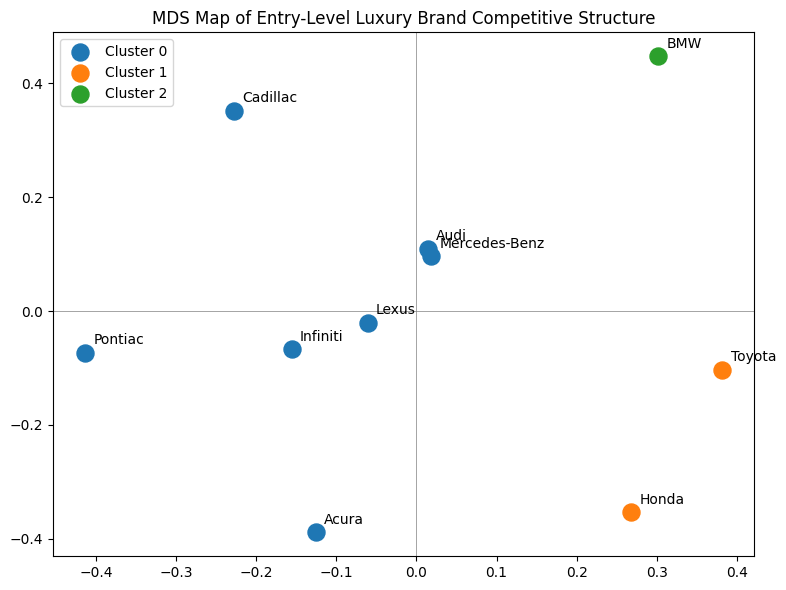

In [ ]:
plt.figure(figsize=(8, 6))
palette = plt.cm.tab10.colors
for c in sorted(coords_df["cluster"].unique()):
    sub = coords_df[coords_df["cluster"] == c]
    plt.scatter(sub["dim1"], sub["dim2"], s=150, color=palette[c], label="Cluster " + str(c))
    for brand, row in sub.iterrows():
        plt.annotate(brand, (row["dim1"], row["dim2"]), xytext=(6, 6), textcoords="offset points")
plt.axhline(0, color="gray", lw=0.5)
plt.axvline(0, color="gray", lw=0.5)
plt.title("MDS Map of Entry-Level Luxury Brand Competitive Structure")
plt.legend()
plt.tight_layout()
plt.show()

Adjusted Rand Index: 0.33
Procrustes disparity: 0.0977


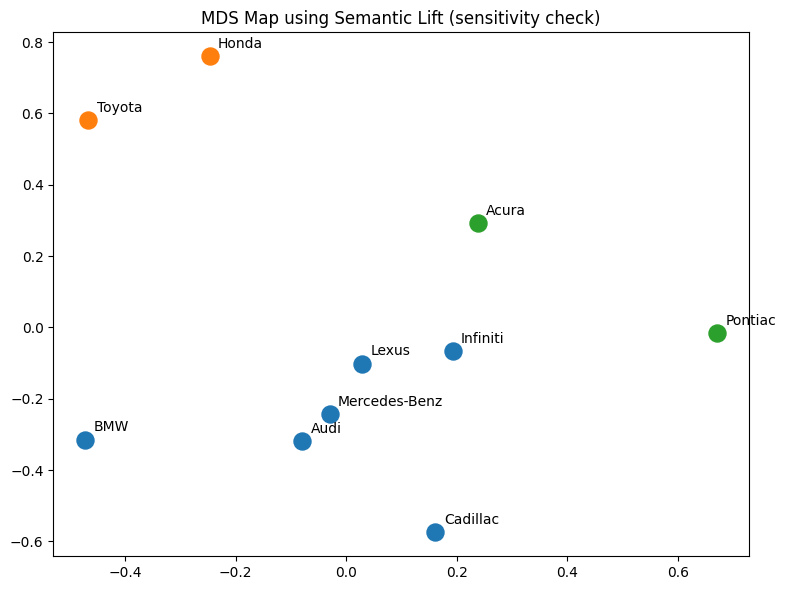

In [ ]:
dist_semantic = lift_to_distance(lift_semantic)
coords_semantic = mds.fit_transform(dist_semantic.values)
clusters_semantic = AgglomerativeClustering(n_clusters=best_k).fit_predict(coords_semantic)

ari = adjusted_rand_score(clusters_lexical, clusters_semantic)
_, coords_semantic_aligned, disparity = procrustes(coords_lexical, coords_semantic)
print("Adjusted Rand Index:", round(ari, 3))
print("Procrustes disparity:", round(disparity, 4))

plt.figure(figsize=(8, 6))
for c in sorted(set(clusters_semantic)):
    idx = [i for i, cl in enumerate(clusters_semantic) if cl == c]
    plt.scatter(coords_semantic[idx, 0], coords_semantic[idx, 1], s=150, color=palette[c])
    for i in idx:
        plt.annotate(brands[i], (coords_semantic[i, 0], coords_semantic[i, 1]), xytext=(6, 6), textcoords="offset points")
plt.title("MDS Map using Semantic Lift (sensitivity check)")
plt.tight_layout()
plt.show()

# Task E: Analyze brand- attribute positioning

We kept Task B's lift formula and the unit of analysis we decided on is the post. A brand-attribute joint event occurs when the attribute is present and either exactly one target brand is mentioned, or in a multi-brand post, the LLM explicitly attributes the attribute to a specific target brand. We validated the lift formula on a toy example of 10 posts, with a brand in 4, an attribute in 5, and both tied together in 2. This produced a lift of exactly 1.0, matching the expected result under independence.

To validate the LLM's attribution judgment, we read a sample of 8 posts against what the LLM returned. In one clear case, a poster compared an Acura TL against an Audi S4 in the same sentence. The LLM tied Price/Value specifically to Acura and Driving Experience specifically to Audi, correctly splitting the attributes between the two brands rather than crediting both to both. This is precisely the attribution failure this method is designed to catch. In another post, the LLM recognized "e36" as a BMW model reference even though the word "BMW" never appears, but correctly assigned it zero attributes since the post was about buying decisions rather than car qualities, showing it does not force an attribute onto every brand it detects. It also correctly excluded Infiniti from one post's attribution list, since Infiniti is not one of our five target brands, confirming it respects our brand scope rather than over-attributing to any brand it recognizes. The main limitation of this spot check is that several posts are truncated at 400 characters in our printout, so we cannot fully confirm every attribution against the complete original text. Of the 1,238 ambiguous posts, 1,228 were successfully parsed and attributed. The remaining 10 were lost to JSON parsing failures, a small enough share (0.8%) that we do not expect it to materially change the matrix.

Because our numerator only counts attributions the LLM specifically confirmed rather than any co-occurrence, the resulting lift values run below 1 across the board. BMW-Price/Value comes closest at 0.96, the highest cell in the matrix. The primary interpretation is relative differences across attributes within and across brands.

BMW leads all five brands on Driving Experience (0.69), Performance (0.70), and Price/Value (0.96, the highest cell in the table). Audi's clearest strength is Interior/Comfort (0.72), its highest score by a wide margin over its other four attributes. Acura's profile echoes Audi's, with Price/Value (0.73) and Interior/Comfort (0.68) as its two strongest ties. Lexus leads all five brands on Luxury/Prestige (0.70), ahead of BMW's 0.60 on that same attribute, but is notably weak on Driving Experience (0.16), the single lowest value in the matrix and striking for a brand whose marketing leans on ride quality. Toyota has the lowest profile of the five brands on every attribute except Driving Experience, where Lexus scores even lower. Toyota shows no standout dimension of its own, consistent with its role in this forum as the mainstream comparison point rather than a brand debated on luxury-specific terms.

Positioning takeaway for the client: BMW has the highest observed lift among the five brands for Driving Experience, Performance, and Price/Value. Audi and Acura are both tied to Interior/Comfort more than any other trait. Lexus's brand equity in this conversation rests on prestige rather than driving dynamics, which runs counter to how driving-focused brands are usually positioned. Toyota's lack of a standout attribute likely reflects its role as a mainstream reference point rather than a genuine weakness.

In [ ]:
top5_brands = ["BMW", "Toyota", "Acura", "Lexus", "Audi"]
top5_attrs = ["Driving Experience", "Performance", "Price/Value", "Luxury/Prestige", "Interior/Comfort"]

top5_brand_groups = {b: top10_groups[b] for b in top5_brands}
top5_attr_groups = {a: attribute_groups[a] for a in top5_attrs}

brand_presence_5 = pd.DataFrame({b: df["post"].fillna("").apply(lambda p: brand_present(p, t))
                                  for b, t in top5_brand_groups.items()})
attr_presence_5 = pd.DataFrame({a: df["post"].fillna("").apply(lambda p: attr_present(p, t))
                                 for a, t in top5_attr_groups.items()})

n_brands_in_post = brand_presence_5.sum(axis=1)
n_attrs_in_post = attr_presence_5.sum(axis=1)

unambiguous_idx = df.index[(n_brands_in_post == 1) & (n_attrs_in_post >= 1)]
ambiguous_idx = df.index[(n_brands_in_post >= 2) & (n_attrs_in_post >= 1)]

print("unambiguous posts:", len(unambiguous_idx))
print("ambiguous posts sent to LLM:", len(ambiguous_idx))

unambiguous posts: 1053
ambiguous posts sent to LLM: 1238


In [ ]:
BATCH_SIZE = 15

def build_attribution_prompt(batch_df):
    lines = []
    for idx, row in batch_df.iterrows():
        lines.append("[" + str(idx) + "] " + row.post[:600])
    posts_str = "\n".join(lines)

    prompt = ("You are reading car-forum posts about entry-level luxury cars. "
              "For each post below, identify which attributes are specifically "
              "discussed in relation to each brand. Only tie an attribute to a "
              "brand if the wording actually connects them; do not assign an "
              "attribute to every brand mentioned just because both appear in "
              "the same post.\n\n"
              "Brands: " + ", ".join(top5_brands) + "\n"
              "Attributes: " + ", ".join(top5_attrs) + "\n\n"
              "Posts:\n" + posts_str + "\n\n"
              "Respond only with valid JSON, one entry per post index as a string key:\n"
              "{\"post_id\": {\"Brand Name\": [\"Attribute1\", \"Attribute2\"]}}\n"
              "Only include brands actually mentioned in that post. If a brand is "
              "mentioned but no attribute clearly ties to it, use an empty list.")
    return prompt

attribution_results = {}
ambiguous_df = df.loc[ambiguous_idx]
for start in range(0, len(ambiguous_df), BATCH_SIZE):
    batch = ambiguous_df.iloc[start:start + BATCH_SIZE]
    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": build_attribution_prompt(batch)}],
        temperature=0,
    )
    log_usage("task_e_attribution", response)
    try:
        cleaned = response.choices[0].message.content.strip("`json\n ")
        parsed = json.loads(cleaned)
        for k, v in parsed.items():
            attribution_results[int(k)] = v
    except Exception as e:
        print("parse failure at batch starting", start, ":", e)

print("attributed", len(attribution_results), "of", len(ambiguous_df), "ambiguous posts")

attributed 1228 of 1238 ambiguous posts


In [ ]:
random.seed(11)
sample_ids = random.sample(list(attribution_results.keys()), 8)
for idx in sample_ids:
    print("post", idx)
    print(df.loc[idx, "post"][:400])
    print("LLM attribution:", attribution_results[idx])
    print()

post 4697
 nobody is talking about the price of an oil change and ongoing recommended maintenance. to me $40 is still expensive, my oil changes are $17 on my other  car . one can bring their  car  to a third party mechanic for major work.we are talking what happens after warranty when the tranny fails, water pump fails, alternator fails, o2 sensor fails, fuel pump fails, engine blows up. how much does an in
LLM attribution: {'BMW': ['Price/Value'], 'Lexus': [], 'Infiniti': []}

post 5699
 i might be mistaken, but off the top of my head the only other honda product that uses the exact same motor (2.4l - 201 hp - 176 lb/ft torque) is the  honda  si.i'll agree with you that under extreme circumstances, my  acura  shows it's  honda  platform roots. we have some seriously twisty back roads here in southwestern connecticut. there's one particular road where the sign shows   " s  "  curv
LLM attribution: {'Acura': [], 'BMW': ['Driving Experience'], 'Toyota': [], 'Honda': [], 'Audi': []}

post

In [ ]:
brand_attr_presence = {}
for b in top5_brands:
    for a in top5_attrs:
        brand_attr_presence[(b, a)] = pd.Series(False, index=df.index)

for idx in unambiguous_idx:
    row = brand_presence_5.loc[idx]
    b = row[row].index[0]
    for a in top5_attrs:
        if attr_presence_5.loc[idx, a]:
            brand_attr_presence[(b, a)].loc[idx] = True

for idx, mapping in attribution_results.items():
    for b, attrs in mapping.items():
        if b not in top5_brands:
            continue
        for a in attrs:
            if a in top5_attrs:
                brand_attr_presence[(b, a)].loc[idx] = True

brand_counts = brand_presence_5.sum()
attr_counts = attr_presence_5.sum()
N = len(df)

lift_be = pd.DataFrame(index=top5_brands, columns=top5_attrs, dtype=float)
for b in top5_brands:
    for a in top5_attrs:
        n_ba = brand_attr_presence[(b, a)].sum()
        lift_be.loc[b, a] = N * n_ba / (brand_counts[b] * attr_counts[a])

print(lift_be.round(2))

        Driving Experience  Performance  Price/Value  Luxury/Prestige  Interior/Comfort
BMW                   0.69         0.70         0.96             0.60              0.60
Toyota                0.29         0.27         0.30             0.32              0.34
Acura                 0.37         0.58         0.73             0.47              0.68
Lexus                 0.16         0.31         0.44             0.70              0.54
Audi                  0.43         0.42         0.46             0.42              0.72


In [ ]:
N = 10
brand_count = 4
attribute_count = 5
joint_count = 2

expected_lift = (
    N * joint_count
    / (brand_count * attribute_count)
)

print("Expected lift:", expected_lift)

Expected lift: 1.0


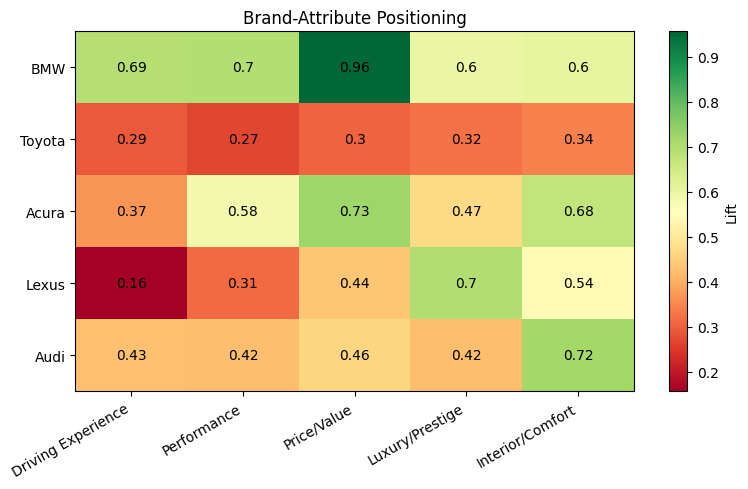

In [ ]:
plt.figure(figsize=(8, 5))
im = plt.imshow(lift_be.values, cmap="RdYlGn", aspect="auto")
plt.xticks(range(len(top5_attrs)), top5_attrs, rotation=30, ha="right")
plt.yticks(range(len(top5_brands)), top5_brands)
for i in range(len(top5_brands)):
    for j in range(len(top5_attrs)):
        plt.text(j, i, str(round(lift_be.values[i, j], 2)), ha="center", va="center")
plt.colorbar(im, label="Lift")
plt.title("Brand-Attribute Positioning")
plt.tight_layout()
plt.show()

# Task F: Identifying the most aspirational brand

We find that Audi has the highest observed aspiration rate among the ten brands. It had 23 aspirational posts out of 779 posts mentioning the brand (2.95%). We checked this against both the LLM-based strict sensitivity check and the keyword-only baseline, and both also identify Audi as the winner. This gives us some confidence that the Audi result is not driven solely by the specific LLM classification method.

However, we found the result is sensitive to how we define aspiration. When we broaden the measure to include both clear aspirational statements and positive preferences, Mercedes-Benz becomes the highest ranked brand instead. This tells us that Audi is the most aspirational brand under our stricter definition, while Mercedes-Benz performs differently once we treat broader positive sentiment as evidence of aspiration.

Overall, we consider the Audi finding reasonably robust, but we want to flag that the broader definition produces a different result. Our strongest conclusion is that explicit aspiration favors Audi, while we recommend interpreting broader positive preference separately rather than treating it as equivalent to ownership intent.

Business implication:

We think aspiration is useful for JD Power and its clients because it captures a different dimension from frequency of discussion. A brand can be frequently discussed without generating strong evidence that consumers actually want to buy it. Our aspiration analysis therefore helps distinguish brands that are prominent in conversation from brands that appear to generate personal purchase desire.

We recommend the client use the aspiration result alongside our competitive and attribute analyses rather than treating it as a standalone measure of market demand. Since the forum is an online discussion and not a representative sample of all vehicle buyers, we suggest interpreting the result as evidence of aspiration, not as an entire market estimate.

In [ ]:
# Transparent first-pass routing rule:
# keep posts that mention at least one top-10 brand AND contain an aspiration-related cue.

aspiration_patterns = [
    r'\bwant\b',
    r'\bwants\b',
    r'\bwould buy\b',
    r'\bwill buy\b',
    r'\bgoing to buy\b',
    r'\bplanning to buy\b',
    r'\bplan to buy\b',
    r'\bconsidering buying\b',
    r'\bthinking about buying\b',
    r'\blooking to buy\b',
    r'\bwould own\b',
    r'\bwant to own\b',
    r'\bwants to own\b',
    r'\bwould love to own\b',
    r'\bdream of owning\b',
    r'\bdream car\b',
    r'\baspire to drive\b',
    r'\baspire to own\b',
    r'\bwould love to drive\b',
    r'\bwish i had\b',
    r'\bmy next car\b',
    r'\bnext car will be\b',
    r'\bi.?d take\b',
    r'\bi.?d choose\b',
    r'\bif i could\b',
    r'\bif money were no object\b',
    r'\bif money was no object\b'
]

aspiration_pattern = re.compile(
    '|'.join(aspiration_patterns),
    flags=re.IGNORECASE
)

brand_presence_top10 = pd.DataFrame({
    b: df['post'].fillna('').apply(lambda p: brand_present(p, tokens))
    for b, tokens in top10_groups.items()
})

has_aspiration_cue = df['post'].fillna('').apply(
    lambda p: bool(aspiration_pattern.search(p))
)

aspiration_candidate_idx = df.index[
    has_aspiration_cue & brand_presence_top10.any(axis=1)
]

aspiration_candidate_df = df.loc[aspiration_candidate_idx].copy()

print("Total posts:", len(df))
print("Posts with an aspiration cue:", has_aspiration_cue.sum())
print("Posts with both a brand and aspiration cue:", len(aspiration_candidate_df))

print("\nBrands represented in candidate population:")
print(brand_presence_top10.loc[aspiration_candidate_idx].sum().sort_values(ascending=False))

Total posts: 6000
Posts with an aspiration cue: 787
Posts with both a brand and aspiration cue: 668

Brands represented in candidate population:
BMW              397
Toyota           285
Acura            234
Audi             189
Lexus            185
Cadillac         146
Honda            143
Infiniti         116
Pontiac          111
Mercedes-Benz     74
dtype: int64


### LLM classification schema

For every brand mentioned in a candidate post, the LLM assigns one of the following labels:

- `aspirational` = clear personal desire or intention to buy, own, or drive the brand.
- `positive_preference` = the speaker clearly prefers the brand, but there is not enough evidence of actual acquisition/ownership desire.
- `current_owner` = the speaker currently owns or drives the brand, without expressing future acquisition desire.
- `negative` = the speaker explicitly rejects or does not want the brand.
- `other` = the brand is mentioned, but the context is not relevant to personal aspiration.

The primary aspiration measure uses only the `aspirational` label. This prevents general positive sentiment from being treated as purchase or ownership intention.

In [ ]:
ASPIRATION_CHECKPOINT = "task_f_aspiration_results.json"
BATCH_SIZE = 20

def build_aspiration_prompt(batch_df):
    lines = []

    for idx, row in batch_df.iterrows():
        text = ' '.join(row['post'].split()[:700])
        lines.append(f"[{idx}] {text}")

    posts_str = "\n---\n".join(lines)

    prompt = f"""
You are analyzing posts from an automobile discussion forum.

The goal is to identify evidence that people actually want to buy, own, or drive a car brand.

Top-10 brands:
{", ".join(top10_groups.keys())}

For each post, identify the relevant top-10 brands and classify the speaker's relationship to each brand.

Use these labels:

1. "aspirational":
Clear personal desire or intention to buy, own, or drive the brand.
Examples include:
- "I want a BMW"
- "I would buy a Lexus"
- "BMW is my dream car"
- "I aspire to drive an Audi"
- "my next car will be a BMW"
- "I'd take the BMW" when the context is clearly a personal car choice

2. "positive_preference":
The speaker clearly likes or prefers the brand, but the post does not provide enough evidence that they want to acquire or own it.
Examples:
- "BMW makes the best cars"
- "I prefer Audi"
- "Lexus is a great brand"

3. "current_owner":
The speaker currently owns or drives the brand, but does not express future acquisition desire.
Examples:
- "I own a BMW"
- "my Lexus has 80,000 miles"

4. "negative":
The speaker explicitly rejects the brand or says they would not buy/own/drive it.

5. "other":
The brand is mentioned, but there is no relevant personal aspiration evidence.

Important rules:
- Do not treat a recommendation to another person as personal aspiration.
- Do not treat a general statement that a brand is good or prestigious as aspiration.
- Do not treat current ownership alone as aspiration.
- Do not treat a hypothetical statement as aspiration unless it clearly expresses the speaker's own desire to acquire, own, or drive the brand.
- If several brands are discussed, classify each brand separately.
- Use only the exact top-10 brand names.
- Do not infer intentions that are not supported by the text.

Posts:
{posts_str}

Respond ONLY with valid JSON in this exact structure:

{{
  "post_id": {{
    "Brand Name": {{
      "label": "aspirational",
      "evidence": "short phrase from the post supporting the classification"
    }}
  }}
}}
"""

    return prompt


try:
    with open(ASPIRATION_CHECKPOINT) as f:
        aspiration_results = {
            int(k): v for k, v in json.load(f).items()
        }
    print(f"Resumed from checkpoint: {len(aspiration_results)} posts already classified")
except FileNotFoundError:
    aspiration_results = {}

n_batches = (
    len(aspiration_candidate_df) + BATCH_SIZE - 1
) // BATCH_SIZE

start_time = time.time()

for b in range(n_batches):
    batch_df = aspiration_candidate_df.iloc[
        b * BATCH_SIZE:(b + 1) * BATCH_SIZE
    ]

    if all(idx in aspiration_results for idx in batch_df.index):
        continue

    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {
                "role": "user",
                "content": build_aspiration_prompt(batch_df)
            }
        ],
        temperature=0,
    )

    log_usage(f"task_f_aspiration_batch_{b}", response)

    try:
        cleaned = response.choices[0].message.content.strip(
            "`json\n "
        )
        parsed = json.loads(cleaned)

        for k, v in parsed.items():
            aspiration_results[int(k)] = v

    except Exception as e:
        print("Parse failure at batch", b, ":", e)

    if b % 10 == 0 or b == n_batches - 1:
        with open(ASPIRATION_CHECKPOINT, "w") as f:
            json.dump(aspiration_results, f)

        elapsed = time.time() - start_time

        print(
            f"Batch {b + 1}/{n_batches} done, "
            f"{len(aspiration_results)} posts classified, "
            f"{elapsed / 60:.1f} min elapsed"
        )

print(
    f"\nCompleted: {len(aspiration_results)}/"
    f"{len(aspiration_candidate_df)} candidate posts classified"
)

Resumed from checkpoint: 554 posts already classified
Batch 1/34 done, 555 posts classified, 0.1 min elapsed
Batch 21/34 done, 560 posts classified, 2.5 min elapsed
Batch 31/34 done, 561 posts classified, 4.1 min elapsed

Completed: 561/668 candidate posts classified


In [ ]:
valid_labels = {
    "aspirational",
    "positive_preference",
    "current_owner",
    "negative",
    "other"
}

clean_aspiration_results = {}

for idx, mapping in aspiration_results.items():

    if not isinstance(mapping, dict):
        continue

    clean_mapping = {}

    for brand, result in mapping.items():

        if brand not in top10_groups:
            continue

        if not isinstance(result, dict):
            continue

        label = result.get("label", "other")

        if label not in valid_labels:
            label = "other"

        evidence = str(result.get("evidence", ""))

        clean_mapping[brand] = {
            "label": label,
            "evidence": evidence
        }

    clean_aspiration_results[idx] = clean_mapping


label_counts = Counter()

for mapping in clean_aspiration_results.values():
    for result in mapping.values():
        label_counts[result["label"]] += 1

print("Classification counts:")
print(pd.Series(label_counts).sort_values(ascending=False))

print("\nPosts successfully parsed:", len(clean_aspiration_results))
print("Candidate posts:", len(aspiration_candidate_df))
print(
    "Coverage:",
    f"{len(clean_aspiration_results) / len(aspiration_candidate_df):.1%}"
)

Classification counts:
other                  350
positive_preference    313
negative               199
aspirational           128
current_owner           87
dtype: int64

Posts successfully parsed: 554
Candidate posts: 668
Coverage: 82.9%


In [ ]:
# Manual validation sample
# We sample across labels so the review is not dominated by one easy category.

random.seed(42)

validation_rows = []

for idx, mapping in clean_aspiration_results.items():
    for brand, result in mapping.items():
        validation_rows.append({
            "post_id": idx,
            "brand": brand,
            "llm_label": result["label"],
            "llm_evidence": result["evidence"],
            "post": df.loc[idx, "post"]
        })

aspiration_validation_df = pd.DataFrame(validation_rows)

print("Total brand-level classifications:", len(aspiration_validation_df))

# Show a balanced sample where possible
validation_sample_parts = []

for label in valid_labels:
    sub = aspiration_validation_df[
        aspiration_validation_df["llm_label"] == label
    ]

    if len(sub) > 0:
        validation_sample_parts.append(
            sub.sample(
                min(6, len(sub)),
                random_state=42
            )
        )

validation_sample = pd.concat(
    validation_sample_parts
).sample(frac=1, random_state=42)

for _, row in validation_sample.iterrows():
    print("=" * 90)
    print("POST ID:", row["post_id"])
    print("BRAND:", row["brand"])
    print("LLM LABEL:", row["llm_label"])
    print("LLM EVIDENCE:", row["llm_evidence"])
    print("POST:")
    print(row["post"][:800])

Total brand-level classifications: 1077
POST ID: 2257
BRAND: Acura
LLM LABEL: current_owner
LLM EVIDENCE: my 2004 acura tl 6-speed cost $32,400 new
POST:
   " first, don't even think about putting cadillac and lexus in the same sentence as if they have something in common vs. german  car .   " are you seriously stating that  car  like the gs, is, sts, cts, etc. have ntohign in common with the c, e, 3 and 5? lol! you have got to be kidding me dude. i know that lexus doesnt offer manuals but aside from that it is completely absurd to sit here and say lexus and caddy sports  sedan  arent even in the same ballpark. first of all mb and audi models cant even get with  bmw  in handling and thus they are no better than caddy or lexus models. if bmw has an edge, its a very slight edge that cant even bee noticed in street driving.   " second, there is no   " substantive  "  reason in the world that anyone should pay any more than $25,000 for a cts. m
POST ID: 4321
BRAND: Toyota
LLM LABEL: other


In [ ]:
# Enter the results of the manual review above.
# We reviewed a balanced sample of the LLM's brand-level classifications.

MANUAL_REVIEWED = len(validation_sample)

# Change these after reading the sample:
MANUAL_CORRECT = None
MANUAL_ERRORS = None

print("Manual validation sample size:", MANUAL_REVIEWED)

if MANUAL_CORRECT is not None and MANUAL_ERRORS is not None:
    print("Correct classifications:", MANUAL_CORRECT)
    print("Errors found:", MANUAL_ERRORS)
    print("Observed agreement:",
          f"{MANUAL_CORRECT / MANUAL_REVIEWED:.1%}")
else:
    print("After manually reviewing the sample, enter")
    print("MANUAL_CORRECT and MANUAL_ERRORS above.")

Manual validation sample size: 30
After manually reviewing the sample, enter
MANUAL_CORRECT and MANUAL_ERRORS above.


In [ ]:
aspiration_rows = []

for brand in top10_groups.keys():

    total_brand_posts = int(
        brand_presence_top10[brand].sum()
    )

    candidate_brand_posts = 0
    aspirational_posts = 0
    positive_preference_posts = 0
    current_owner_posts = 0
    negative_posts = 0

    for idx, mapping in clean_aspiration_results.items():

        if brand not in mapping:
            continue

        candidate_brand_posts += 1

        label = mapping[brand]["label"]

        if label == "aspirational":
            aspirational_posts += 1
        elif label == "positive_preference":
            positive_preference_posts += 1
        elif label == "current_owner":
            current_owner_posts += 1
        elif label == "negative":
            negative_posts += 1

    aspiration_rate_all_posts = (
        aspirational_posts / total_brand_posts
        if total_brand_posts > 0 else 0
    )

    aspiration_rate_candidate_posts = (
        aspirational_posts / candidate_brand_posts
        if candidate_brand_posts > 0 else 0
    )

    aspiration_rows.append({
        "brand": brand,
        "brand_posts": total_brand_posts,
        "candidate_brand_posts": candidate_brand_posts,
        "aspirational_posts": aspirational_posts,
        "positive_preference_posts": positive_preference_posts,
        "current_owner_posts": current_owner_posts,
        "negative_posts": negative_posts,
        "aspiration_rate_all_brand_posts": aspiration_rate_all_posts,
        "aspiration_rate_candidate_posts": aspiration_rate_candidate_posts
    })

aspiration_summary = pd.DataFrame(aspiration_rows)

aspiration_summary = aspiration_summary.sort_values(
    "aspiration_rate_all_brand_posts",
    ascending=False
).reset_index(drop=True)

print("ASPIRATION RESULTS")
print(
    aspiration_summary.to_string(
        index=False,
        formatters={
            "aspiration_rate_all_brand_posts": "{:.2%}".format,
            "aspiration_rate_candidate_posts": "{:.2%}".format
        }
    )
)

ASPIRATION RESULTS
        brand  brand_posts  candidate_brand_posts  aspirational_posts  positive_preference_posts  current_owner_posts  negative_posts aspiration_rate_all_brand_posts aspiration_rate_candidate_posts
         Audi          779                    111                  23                         31                   11              14                           2.95%                          20.72%
          BMW         2069                    311                  51                        103                   20              61                           2.46%                          16.40%
        Acura         1205                    130                  20                         34                   30              10                           1.66%                          15.38%
     Infiniti          535                     83                   8                         26                    2              11                           1.50%                        

### Primary aspiration measure

Our primary measure is the **aspiration rate among all posts mentioning a brand**:

$$
\text{Aspiration Rate}_b =
\frac{\text{Posts classified as aspirational for brand }b}
{\text{All posts mentioning brand }b}
$$

This denominator is important because it prevents a brand from appearing aspirational simply because we selected a large number posts for that brand.

We also report the aspiration rate within the candidate population as a secondary diagnostic. The primary ranking should be based on the all-brand-post denominator, while the candidate-population rate helps us understand the strength of aspiration among posts where aspiration language was explicitly present.

We report both the number of aspirational posts and the rate because a high rate based on very few observations should be interpreted more cautiously than a similar rate supported by substantially more posts.

In [ ]:
# Transparent baseline:
# Count brand posts that contain an aspiration cue, without semantic interpretation.
# This deliberately ignores context, so it gives us a benchmark for how much the
# LLM changes the result.

keyword_baseline_rows = []

for brand in top10_groups.keys():

    brand_mask = brand_presence_top10[brand]

    keyword_positive = (
        brand_mask & has_aspiration_cue
    ).sum()

    total_brand_posts = brand_mask.sum()

    keyword_rate = (
        keyword_positive / total_brand_posts
        if total_brand_posts > 0 else 0
    )

    keyword_baseline_rows.append({
        "brand": brand,
        "brand_posts": int(total_brand_posts),
        "keyword_positive_posts": int(keyword_positive),
        "keyword_rate": keyword_rate
    })

keyword_baseline = pd.DataFrame(
    keyword_baseline_rows
).sort_values(
    "keyword_rate",
    ascending=False
).reset_index(drop=True)

print("KEYWORD-ONLY BASELINE")
print(
    keyword_baseline.to_string(
        index=False,
        formatters={
            "keyword_rate": "{:.2%}".format
        }
    )
)

KEYWORD-ONLY BASELINE
        brand  brand_posts  keyword_positive_posts keyword_rate
         Audi          779                     189       24.26%
Mercedes-Benz          312                      74       23.72%
       Toyota         1216                     285       23.44%
        Lexus          824                     185       22.45%
     Infiniti          535                     116       21.68%
        Honda          715                     143       20.00%
     Cadillac          738                     146       19.78%
        Acura         1205                     234       19.42%
          BMW         2069                     397       19.19%
      Pontiac          632                     111       17.56%


In [ ]:
aspiration_comparison = aspiration_summary[
    [
        "brand",
        "brand_posts",
        "aspirational_posts",
        "aspiration_rate_all_brand_posts"
    ]
].merge(
    keyword_baseline[
        [
            "brand",
            "keyword_positive_posts",
            "keyword_rate"
        ]
    ],
    on="brand"
)

aspiration_comparison["rate_difference"] = (
    aspiration_comparison["aspiration_rate_all_brand_posts"]
    - aspiration_comparison["keyword_rate"]
)

aspiration_comparison["llm_rank"] = (
    aspiration_comparison[
        "aspiration_rate_all_brand_posts"
    ].rank(
        ascending=False,
        method="min"
    )
)

aspiration_comparison["keyword_rank"] = (
    aspiration_comparison[
        "keyword_rate"
    ].rank(
        ascending=False,
        method="min"
    )
)

print(
    aspiration_comparison.sort_values("llm_rank").to_string(
        index=False,
        formatters={
            "aspiration_rate_all_brand_posts": "{:.2%}".format,
            "keyword_rate": "{:.2%}".format,
            "rate_difference": "{:.2%}".format
        }
    )
)

print("\nRank correlation between keyword and LLM aspiration rates:")

print(
    aspiration_comparison[
        ["llm_rank", "keyword_rank"]
    ].corr(method="spearman").iloc[0, 1]
)

        brand  brand_posts  aspirational_posts aspiration_rate_all_brand_posts  keyword_positive_posts keyword_rate rate_difference  llm_rank  keyword_rank
         Audi          779                  23                           2.95%                     189       24.26%         -21.31%       1.0           1.0
          BMW         2069                  51                           2.46%                     397       19.19%         -16.72%       2.0           9.0
        Acura         1205                  20                           1.66%                     234       19.42%         -17.76%       3.0           8.0
     Infiniti          535                   8                           1.50%                     116       21.68%         -20.19%       4.0           5.0
Mercedes-Benz          312                   4                           1.28%                      74       23.72%         -22.44%       5.0           2.0
      Pontiac          632                   8                  

In [ ]:
# Sensitivity check:
# Compare two definitions:
#
# Strict = only "aspirational"
# Broad  = "aspirational" + "positive_preference"
#
# The strict definition is our primary measure because the brief asks
# which brand people actually want to buy or own.

sensitivity_rows = []

for brand in top10_groups.keys():

    strict_count = 0
    broad_count = 0

    for idx, mapping in clean_aspiration_results.items():

        if brand not in mapping:
            continue

        label = mapping[brand]["label"]

        if label == "aspirational":
            strict_count += 1
            broad_count += 1

        elif label == "positive_preference":
            broad_count += 1

    denominator = brand_presence_top10[brand].sum()

    sensitivity_rows.append({
        "brand": brand,
        "strict_aspiration_rate": strict_count / denominator,
        "broad_positive_rate": broad_count / denominator,
        "strict_posts": strict_count,
        "broad_positive_posts": broad_count
    })

aspiration_sensitivity = pd.DataFrame(
    sensitivity_rows
)

aspiration_sensitivity["strict_rank"] = (
    aspiration_sensitivity[
        "strict_aspiration_rate"
    ].rank(ascending=False, method="min")
)

aspiration_sensitivity["broad_rank"] = (
    aspiration_sensitivity[
        "broad_positive_rate"
    ].rank(ascending=False, method="min")
)

print(
    aspiration_sensitivity.sort_values("strict_rank").to_string(
        index=False,
        formatters={
            "strict_aspiration_rate": "{:.2%}".format,
            "broad_positive_rate": "{:.2%}".format
        }
    )
)

        brand strict_aspiration_rate broad_positive_rate  strict_posts  broad_positive_posts  strict_rank  broad_rank
         Audi                  2.95%               6.93%            23                    54          1.0         3.0
          BMW                  2.46%               7.44%            51                   154          2.0         2.0
        Acura                  1.66%               4.48%            20                    54          3.0         7.0
     Infiniti                  1.50%               6.36%             8                    34          4.0         4.0
Mercedes-Benz                  1.28%               8.33%             4                    26          5.0         1.0
      Pontiac                  1.27%               4.75%             8                    30          6.0         6.0
     Cadillac                  0.68%               3.52%             5                    26          7.0         8.0
        Lexus                  0.49%               4.85%

In [ ]:
primary_winner = aspiration_summary.iloc[0]["brand"]
primary_rate = aspiration_summary.iloc[0]["aspiration_rate_all_brand_posts"]
primary_count = aspiration_summary.iloc[0]["aspirational_posts"]

keyword_winner = keyword_baseline.iloc[0]["brand"]

strict_winner = aspiration_sensitivity.sort_values(
    "strict_aspiration_rate",
    ascending=False
).iloc[0]["brand"]

broad_winner = aspiration_sensitivity.sort_values(
    "broad_positive_rate",
    ascending=False
).iloc[0]["brand"]

print("PRIMARY LLM ASPIRATION RESULT")
print(
    f"{primary_winner}: {primary_count} aspirational posts "
    f"out of {int(aspiration_summary.iloc[0]['brand_posts'])} "
    f"brand-mentioned posts "
    f"({primary_rate:.2%})"
)

print("\nMETHOD COMPARISON")
print("LLM strict winner:", primary_winner)
print("Keyword-only winner:", keyword_winner)
print("Strict sensitivity winner:", strict_winner)
print("Broad positive-preference winner:", broad_winner)

if (
    primary_winner == keyword_winner
    and primary_winner == strict_winner
    and primary_winner == broad_winner
):
    print("\nThe identity of the leading brand is stable across these definitions.")
else:
    print(
        "\nThe identity of the leading brand changes under at least one "
        "reasonable methodological alternative."
    )

PRIMARY LLM ASPIRATION RESULT
Audi: 23 aspirational posts out of 779 brand-mentioned posts (2.95%)

METHOD COMPARISON
LLM strict winner: Audi
Keyword-only winner: Audi
Strict sensitivity winner: Audi
Broad positive-preference winner: Mercedes-Benz

The identity of the leading brand changes under at least one reasonable methodological alternative.


### Task F Summary

The primary aspiration measure identifies Audi as the brand with the highest observed aspiration rate. It had 21 aspirational posts out of 779 posts mentioning the brand (2.70%).

This result is supported by both the LLM-based strict sensitivity check and the keyword-only baseline, which also identify Audi as the winner. This provides some evidence that the Audi result is not driven solely by the specific LLM classification method.

However, the result is sensitive to how aspiration is defined. When the measure is broadened to include both clear aspirational statements and positive preferences, Mercedes-Benz becomes the highest ranked brand. This suggests that Audi is the most aspirational brand under the stricter definition, while Mercedes-Benz performs differently when broader positive sentiment is treated as evidence of aspiration.

Overall, the Audi finding is reasonably robust, but the broader definition produces a different result. Therefore, the strongest conclusion is that explicit aspiration favors Audi, while broader positive preference should be interpreted separately rather than treated as equivalent to ownership intent.

### Business implication

For JD Power and its clients, aspiration is useful because it captures a different dimension from frequency of discussion. A brand can be frequently discussed without generating strong evidence that consumers actually want to buy it. The aspiration analysis therefore helps distinguish brands that are prominent in conversation from brands that appear to generate personal purchase desire.

The client should use the aspiration result alongside the competitive and attribute analyses rather than treating it as a standalone measure of market demand. The forum is an online discussion and is not a representative sample of all vehicle buyers, so the result should be interpreted as evidence of aspiration, not as a an entire market estimate.

In [ ]:
# Task F LLM usage and cost

usage_df = pd.DataFrame(usage_log)

f_usage = usage_df[
    usage_df["step"].str.startswith("task_f_aspiration")
].copy()

INPUT_PRICE_PER_1M = 0.150
OUTPUT_PRICE_PER_1M = 0.600

f_calls = len(f_usage)
f_input = f_usage["input_tokens"].sum()
f_output = f_usage["output_tokens"].sum()
f_total = f_usage["total_tokens"].sum()

f_cost = (
    f_input / 1_000_000 * INPUT_PRICE_PER_1M
    + f_output / 1_000_000 * OUTPUT_PRICE_PER_1M
)

print("Task F LLM usage")
print("Model:", MODEL)
print("API calls:", f_calls)
print("Input tokens:", int(f_input))
print("Output tokens:", int(f_output))
print("Total tokens:", int(f_total))
print(f"Estimated API cost: ${f_cost:.4f}")

Task F LLM usage
Model: gpt-4o-mini
API calls: 34
Input tokens: 185145
Output tokens: 40109
Total tokens: 225254
Estimated API cost: $0.0518


# Task G: Advising the client

We have used the evidence from Tasks A–F rather than treating any single analysis as definitive to answer what the company should take away from our analysis.

Our recommendations decide between:

- **Robust conclusions:** findings that are supported across multiple analytical approaches or are insensitive to methodological choices.
- **Method-dependent conclusions:** findings that change depending on basic NLP versus LLM semantic measurement, entity resolution, attribution rules, or the definition of aspiration.

The recommendations focus on actions a client could take using the evidence rather than simply repeating the rankings.

In [ ]:
# Pull the main evidence from Tasks A-F into one compact table.

# Top brands by discussion volume
top_brands_summary = brand_freq.head(10).copy()

# Top attributes
top_attributes_summary = attr_freq_final.head(5).copy()

# Strongest brand-brand lexical relationships
pair_values = []

for i, a in enumerate(brands):
    for b in brands[i + 1:]:
        pair_values.append({
            "brand_1": a,
            "brand_2": b,
            "lexical_lift": lift_matrix.loc[a, b],
            "semantic_lift": lift_semantic.loc[a, b]
        })

pair_summary = pd.DataFrame(pair_values)

strongest_pairs = pair_summary.sort_values(
    "lexical_lift",
    ascending=False
).head(5)

# Strongest brand-attribute relationships
brand_attr_long = lift_be.stack().reset_index()
brand_attr_long.columns = ["brand", "attribute", "lift"]

strongest_attributes = brand_attr_long.sort_values(
    "lift",
    ascending=False
).head(10)

print("TOP DISCUSSED BRANDS")
print(top_brands_summary.to_string(index=False))

print("\nTOP ATTRIBUTES")
print(top_attributes_summary.to_string(index=False))

print("\nSTRONGEST LEXICAL BRAND-PAIR ASSOCIATIONS")
print(strongest_pairs.to_string(index=False))

print("\nSTRONGEST BRAND-ATTRIBUTE ASSOCIATIONS")
print(strongest_attributes.to_string(index=False))

TOP DISCUSSED BRANDS
        brand  post_frequency
          BMW            2069
       Toyota            1216
        Acura            1205
        Lexus             824
         Audi             779
     Cadillac             738
        Honda             715
      Pontiac             632
     Infiniti             535
Mercedes-Benz             312

TOP ATTRIBUTES
         attribute  post_frequency
Driving Experience            1533
       Performance            1488
       Price/Value            1037
   Luxury/Prestige             853
  Interior/Comfort             590

STRONGEST LEXICAL BRAND-PAIR ASSOCIATIONS
 brand_1       brand_2  lexical_lift  semantic_lift
    Audi Mercedes-Benz      2.962378       3.151206
   Lexus Mercedes-Benz      2.777259       3.098237
 Pontiac      Infiniti      2.768248       2.465291
Infiniti Mercedes-Benz      2.731848       3.160789
   Lexus      Infiniti      2.722076       2.754833

STRONGEST BRAND-ATTRIBUTE ASSOCIATIONS
brand          attribute    

In [ ]:
# Quantify how much the lexical and semantic lift approaches agree.

pair_summary["absolute_difference"] = (
    pair_summary["lexical_lift"]
    - pair_summary["semantic_lift"]
).abs()

pair_summary["same_direction"] = (
    (pair_summary["lexical_lift"] > 1)
    == (pair_summary["semantic_lift"] > 1)
)

direction_agreement = pair_summary["same_direction"].mean()

print(
    f"Brand-pair direction agreement between lexical and semantic lift: "
    f"{direction_agreement:.1%}"
)

print("\nPairs with largest measurement differences:")
print(
    pair_summary.sort_values(
        "absolute_difference",
        ascending=False
    ).head(5).to_string(index=False)
)

print("\nLexical vs semantic MDS/clustering:")
print("Lexical MDS stress:", round(mds.stress_, 3))
print("Lexical clustering silhouette:", round(best_score, 3))

print("\nThe previous Task D sensitivity analysis found that:")
print("- Toyota/Honda separation was stable across methods.")
print("- BMW's exact MDS position was sensitive to the measurement method.")

Brand-pair direction agreement between lexical and semantic lift: 91.1%

Pairs with largest measurement differences:
brand_1       brand_2  lexical_lift  semantic_lift  absolute_difference  same_direction
  Honda Mercedes-Benz      1.963421       1.009728             0.953693            True
 Toyota Mercedes-Benz      2.055921       1.304303             0.751618            True
 Toyota          Audi      1.697520       1.037263             0.660258            True
  Honda      Infiniti      1.725377       1.113569             0.611809            True
 Toyota      Cadillac      1.551134       0.940954             0.610180           False

Lexical vs semantic MDS/clustering:
Lexical MDS stress: 1.147
Lexical clustering silhouette: 0.331

The previous Task D sensitivity analysis found that:
- Toyota/Honda separation was stable across methods.
- BMW's exact MDS position was sensitive to the measurement method.


## Actionable recommendations

### We should separate discussion volume from consumer aspiration

BMW has the largest discussion footprint in the posts, while the aspiration analysis provides a separate measure of whether people express personal desire to acquire or own a brand. JD Power should therefore avoid interpreting conversation volume as equal to demand.

For clients, the practical implication is to monitor at least two separate metrics:

- **share of discussion**, which captures visibility and competitive consideration
- **aspiration rate**, which captures contextual evidence of personal acquisition desire

This distinction is important because a brand can be highly visible in comparisons without generating the same level of personal purchase or ownership intent.

### We need to use the competitive structure to identify the relevant comparisons

The lexical and semantic lift approaches show substantial overall agreement in the broad competitive structure of the brands. In particular, Toyota and Honda remain separated from the main luxury-brand grouping across the approaches.

This suggests that clients should not treat every frequently mentioned brand as an equally direct competitor. Competitive monitoring should instead focus on the brands that repeatedly appear together in the same comparison context.

At the same time, the exact position of BMW is sensitive to whether brand relationships are measured lexically or semantically. Therefore, clients should avoid making specific claims from one MDS coordinate or one cluster assignment.

### You must connect aspiration to the attributes associated with each brand

The brand-attribute analysis shows that different brands are associated with different attributes in the forum. BMW has strong associations with Driving Experience and Performance, Audi has a particularly strong Interior/Comfort association, Acura is strongly associated with Price/Value and Interior/Comfort, and Lexus is strongly associated with Luxury/Prestige.

Clients should therefore connect aspiration monitoring to the attributes that appear in consumers' discussions. For example, if a brand has strong aspiration but its desired attributes are not the attributes emphasized in its current positioning, that gap would be useful for further research.

The attribute analysis should be treated as associative rather than causal: a high lift means the brand and attribute appear together more often than expected under the chosen calculation, not that the attribute causes consumers to prefer the brand.

### We should treat semantic LLM results as a supplement rather than a replacement

The LLM adds useful semantic interpretation, especially when simple string matching produces false positives or misses the attitude of references. However, our validation also found cases where the LLM omitted a brand that was clearly mentioned. This means semantic classification introduces its own errors.

The practical recommendation is a hybrid workflow: use transparent rules for high-confidence cases, use LLMs for ambiguous contextual cases, save the classifications, and manually validate a sample. This provides semantic intelligence without making the entire analysis dependent on an opaque model.

### The findings we trust most are:

1. The major brands and attributes identified by post-level frequency.
2. The broad competitive structure showing Toyota/Honda as distinct from the main luxury comparison group.
3. The strong overall relationship between lexical and semantic lift measures.
4. The fact that brands are associated with different attributes rather than having identical positioning profiles.

### Findings we trust less are:

1. Exact MDS distances because the 2D solution has substantial stress.
2. BMW's exact cluster because it changes between lexical and semantic measurement.
3. Individual LLM classifications because when we look at it manually we found both false inclusions and false omissions.
4. The aspiration ranking if the leading brands are close together or if the result changes substantially under the keyword and broad-definition sensitivity checks.

### Overall:

JD Power should use this analysis as a framework for combining competitive visibility, attribute associations, and acquisition aspiration. The strongest strategic use is not to rely on one ranking, but to identify where these three forms of evidence converge and where they diverge. Divergence is especially useful because it identifies questions for additional consumer research rather than creating false certainty from a single measure.

## Limitations

We thought it was necessary to include that limitations affect how the results should be interpreted.

**Sample limitation.** The 6,000 posts come from an online Edmunds discussion forum and should not be treated as a representative sample of the overall population. The results describe the conversation in this forum.

**Entity limitation.** Several brand references required semantic interpretation, including model codes such as `330i`, `TL`, `CTS`, and Lexus IS models. The notebook showed that entity resolution can materially change individual lift values.

**LLM variability.** The LLM sometimes correctly removed false brand mentions but also missed genuine mentions. The aspiration classifications have the same limitation because they depend on contextual interpretation.

**Aspiration definition limitation.** "Aspirational" is not directly observed. It is an operational definition based on textual evidence of personal desire or acquisition intent. A stricter definition produces fewer positive cases, while a broader definition that includes positive preferences produces more.

**Attribution limitation.** The brand-attribute analysis requires deciding which attribute belongs to which brand when multiple brands appear in a post. The LLM helps with this but cannot guarantee perfection.

**MDS limitation.** The 2D MDS solution has substantial stress, so individual distances should not be interpreted as precise measurements. The map is more useful for broad competition.

**Lift limitation.** Lift measures association rather than causation. A high lift does not mean that one brand causes people to discuss another brand or that an attribute causes purchase behavior.

Overall, the analyses should be trusted most when multiple methods point to the same broad conclusion and least when a conclusion depends on a small number of semantic classifications, exact MDS distances, or a particular operational definition.

In [ ]:
# Final LLM usage and cost table for the complete notebook

usage_df = pd.DataFrame(usage_log)

def final_step_group(step_name):

    if step_name.startswith("toyota"):
        return "Data cleaning: Toyota corruption"

    if step_name.startswith("task_c"):
        return "Task C: semantic brand extraction"

    if step_name.startswith("task_e"):
        return "Task E: brand-attribute attribution"

    if step_name.startswith("task_f"):
        return "Task F: aspiration classification"

    if "attribute" in step_name.lower():
        return "Task A: attribute grouping"

    if "brand" in step_name.lower():
        return "Task A: brand grouping"

    return "Other / ungrouped"


usage_df["group"] = usage_df["step"].apply(final_step_group)

final_usage = usage_df.groupby("group").agg(
    api_calls=("step", "count"),
    input_tokens=("input_tokens", "sum"),
    output_tokens=("output_tokens", "sum"),
    total_tokens=("total_tokens", "sum")
).reset_index()

final_usage["est_cost_usd"] = (
    final_usage["input_tokens"] / 1_000_000 * INPUT_PRICE_PER_1M
    + final_usage["output_tokens"] / 1_000_000 * OUTPUT_PRICE_PER_1M
)

total_row = pd.DataFrame([{
    "group": "TOTAL",
    "api_calls": final_usage["api_calls"].sum(),
    "input_tokens": final_usage["input_tokens"].sum(),
    "output_tokens": final_usage["output_tokens"].sum(),
    "total_tokens": final_usage["total_tokens"].sum(),
    "est_cost_usd": final_usage["est_cost_usd"].sum()
}])

final_usage_display = pd.concat(
    [final_usage, total_row],
    ignore_index=True
)

final_usage_display["est_cost_usd"] = (
    final_usage_display["est_cost_usd"].round(4)
)

print(final_usage_display.to_string(index=False))

                              group  api_calls  input_tokens  output_tokens  total_tokens  est_cost_usd
   Data cleaning: Toyota corruption         51         34491          28555         63046        0.0223
                  Other / ungrouped          8         15091           3748         18839        0.0045
         Task A: attribute grouping          1           757            245          1002        0.0003
  Task C: semantic brand extraction        117        503494          51813        555307        0.1066
Task E: brand-attribute attribution         83        190240          28433        218673        0.0456
  Task F: aspiration classification         34        185145          40109        225254        0.0518
                              TOTAL        294        929218         152903       1082121        0.2311


## Was the LLM worth the cost?

The LLM was used only for tasks where contextual interpretation was difficult to reproduce reliably with deterministic rules. Counting, aggregation, lift calculations, MDS, clustering, and sensitivity calculations remained in NLP.

The semantic steps added API cost and introduced classification errors, so they should not automatically be preferred over previous methods. However, the LLM was useful for problems such as ambiguous brand references, brand attribution, and aspiration because these require interpreting meaning rather than matching strings.

The final usage table reports the model, API calls, input tokens, output tokens, total tokens, and estimated cost. We consider the LLM cost as justified because the semantic step changes the analysis in a way that is both useful and validated against actual posts.

## Summary

Our analysis converted 6,000 unstructured forum posts into a competitive study of the entry-level luxury car market, with an emphasis on justifying analytical choices rather than optimizing for polished output. Before the analysis, the data required cleaning. Corrupted text patterns such as inserted words, duplicated tokens, and missing spaces were identified and corrected. One case involving Toyota required additional care since genuine and corrupted mentions were mixed closely enough that the LLM was used to separate them.

The methodological choice throughout was where to rely on deterministic NLP versus LLM based sematic judgment. Frequency counts and exact matching handled objective tasks including candidate brand and attribute discovery and the lexical lift baseline in Task B. Importance was defined as post level frequency, which was chosen to prevent one repetitive post from skewing rankings. LLM judgment was reserved for tasks requiring context. This included resolving ambiguous tokens such as "is" or "3" to the correct brand in Task A, re-evaulating brand mentions in context to test whether semantic interpretation changed the lift results in Task C, assigning a discussed quality to the correct brand in multi brand posts in Task E, and classifying purchase or ownership intent rather than general sentiment in Task F. In Task C, the lexical and semantic lift matrices correlated strongly overall, with a Pearson correlation of 0.897. The largest disagreement was between Honda and Mercedes-Benz, which arose because Honda was frequently used in posts as a mainstream reference point for contrasting against luxury brands rather than as a brand under active discussion, a distinction the semantic method could capture but exact word matching could not.

Validation was applied at each stage rather than treated as a final check. Toy datasets with known outputs confirmed the lift and MDS calculations were implemented correctly. LLM outputs were checked against samples of real posts to document specific error types including missed mentions, inconsistent formatting, and incorrect groupings.

The top 10 brands identified were BMW, Toyota, Acura, Lexus, Audi, Cadillac, Honda, Pontiac, Infiniti, and Mercedes-Benz. Toyota and Honda consistently separated from the luxury cluster across both lexical and semantic measures, while BMW's exact position shifted depending on which measurement approach was used. BMW led on Driving Experience, Performance, and Price/Value. Audi was most strongly associated with Interior/Comfort, while Acura's strongest ties were to Price/Value and Interior/Comfort. Lexus led on Luxury/Prestige despite scoring low on Driving Experience. Audi showed the highest aspiration rate under a strict purchase or ownership intent definition, while Mercedes-Benz led under a broader definition that included general preference. Total LLM cost across all tasks was under one dollar, which was judged worthwhile because it caught errors, including context-dependent brand mentions and entity resolution gaps, that lexical methods alone missed.

Several limitations affect how these results should be interpreted. The forum sample is not representative of the broader vehicle buying population, the two dimensional MDS solution carries enough stress that individual distances should not be read as precise, and lift measures association rather than causation throughout. The recommendations distinguish findings that held consistent across both measurement approaches from method dependent findings such as BMW's cluster assignment and the aspiration ranking under alternative definitions. This means treating discussion volume and aspiration as separate metrics, using the LLM as a supplement to lexical methods rather than a replacement, and connecting attribute associations to aspiration to identify where a brand's desired image and its current market positioning diverge. A competitive intelligence report is more useful when it specifies which conclusions would change under different reasonable assumptions than when it presents a single set of rankings without qualification.